<a href="https://colab.research.google.com/github/mjgilson67/Spotify-Data-Analysis/blob/main/Data_Science_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import statsmodels.formula.api as smf
from google.colab import drive


In [ ]:
files = glob.glob('/content/drive/MyDrive/Spotify_Data/Streaming_History_Audio_20*.json')
data_list = []
for file in files:
  with open(file, 'r', encoding='utf-8') as f:
    data = json.load(f)
    data_list.extend(data)

df = pd.DataFrame(data_list)
print(df.head())


                     ts                platform  ms_played conn_country  \
0  2018-01-05T17:18:45Z  iOS 11.2.1 (iPhone8,4)     228136           US   
1  2018-01-05T17:20:00Z  iOS 11.2.1 (iPhone8,4)      31045           US   
2  2018-01-05T17:20:50Z  iOS 11.2.1 (iPhone8,4)      49319           US   
3  2018-01-05T17:20:57Z  iOS 11.2.1 (iPhone8,4)       6780           US   
4  2018-01-05T17:21:52Z  iOS 11.2.1 (iPhone8,4)      54636           US   

           ip_addr master_metadata_track_name  \
0  166.176.122.145            Little Dark Age   
1  166.176.122.145            Little Dark Age   
2  166.176.122.145               Hand It Over   
3  166.176.122.145       Never Is a Long Time   
4  166.176.122.145                How It Ends   

  master_metadata_album_artist_name          master_metadata_album_album_name  \
0                              MGMT                           Little Dark Age   
1                              MGMT                           Little Dark Age   
2          

Here I called my data. The source was Spotify itself. The platform was Spotify's website where you can request your extended listening history. It comes in JSON files from each year, sometimes multiple for a year, and is divided into video and audio files. Time goes from 2018 to 2026. The data represents the songs I've listened to by their title, artist, album, time listened to, duration, and some information on how i listened to it (shuffle or not) and why i stopped listening(skip or pause).

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206791 entries, 0 to 206790
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   ts                                 206791 non-null  object 
 1   platform                           206791 non-null  object 
 2   ms_played                          206791 non-null  int64  
 3   conn_country                       206782 non-null  object 
 4   ip_addr                            206782 non-null  object 
 5   master_metadata_track_name         204746 non-null  object 
 6   master_metadata_album_artist_name  204746 non-null  object 
 7   master_metadata_album_album_name   204746 non-null  object 
 8   spotify_track_uri                  204746 non-null  object 
 9   episode_name                       1995 non-null    object 
 10  episode_show_name                  1995 non-null    object 
 11  spotify_episode_uri                1995

In [ ]:
df['minutes_played'] = df['ms_played'] / 60000

Here I'm looking through all the different variables and I find out that there are podcasts in my listening data, which I don't want. I also turn ms into minutes which makes the time listened to more comprehensible.

In [ ]:
print(df.isnull().sum())

ts                                        0
platform                                  0
ms_played                                 0
conn_country                              9
ip_addr                                   9
master_metadata_track_name             2045
master_metadata_album_artist_name      2045
master_metadata_album_album_name       2045
spotify_track_uri                      2045
episode_name                         204796
episode_show_name                    204796
spotify_episode_uri                  204796
audiobook_title                      206755
audiobook_uri                        206755
audiobook_chapter_uri                206755
audiobook_chapter_title              206761
reason_start                              0
reason_end                                0
shuffle                                   0
skipped                                   0
offline                                   0
offline_timestamp                     95998
incognito_mode                  

Now I need to see the Specific Null values. I see that there are 2045 null songs which have probably been removed off spotify or they are pirated songs which were deleted.

In [ ]:
!pip install spotipy


In [ ]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from google.colab import userdata
auth_manager = SpotifyClientCredentials(
    client_id = userdata.get('Spotify_Client_ID'),
    client_secret = userdata.get('Spotify_Client_Secret')
)
sp = spotipy.Spotify(auth_manager=auth_manager)

Here is me trying to call the Spotify API, which works disastrously.

In [ ]:
df_music = df[df['spotify_track_uri'].notnull()].copy()
print(len(df))
print(len(df_music))
x = len(df) - len(df_music)
print(x)

206791
204746
2045


Here I'm trying to figure out how many songs I've listened to that are songs with information and those without info.

In [ ]:
df_music = df_music.dropna(subset=["master_metadata_track_name", "master_metadata_album_album_name", "master_metadata_album_artist_name"])
print(len(df_music))

204746


I drop what I don't need and see the length.

In [ ]:
df_music.info()

<class 'pandas.core.frame.DataFrame'>
Index: 204746 entries, 0 to 206790
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   ts                                 204746 non-null  object 
 1   platform                           204746 non-null  object 
 2   ms_played                          204746 non-null  int64  
 3   conn_country                       204737 non-null  object 
 4   ip_addr                            204737 non-null  object 
 5   master_metadata_track_name         204746 non-null  object 
 6   master_metadata_album_artist_name  204746 non-null  object 
 7   master_metadata_album_album_name   204746 non-null  object 
 8   spotify_track_uri                  204746 non-null  object 
 9   episode_name                       0 non-null       object 
 10  episode_show_name                  0 non-null       object 
 11  spotify_episode_uri                0 non-nul

One more look for good measure.

In [ ]:
print(df_music.isnull().sum())

ts                                        0
platform                                  0
ms_played                                 0
conn_country                              9
ip_addr                                   9
master_metadata_track_name                0
master_metadata_album_artist_name         0
master_metadata_album_album_name          0
spotify_track_uri                         0
episode_name                         204746
episode_show_name                    204746
spotify_episode_uri                  204746
audiobook_title                      204746
audiobook_uri                        204746
audiobook_chapter_uri                204746
audiobook_chapter_title              204746
reason_start                              0
reason_end                                0
shuffle                                   0
skipped                                   0
offline                                   0
offline_timestamp                     95801
incognito_mode                  

I have now pretty much completed my data cleaning. I wont use offline timestamps for anything and the episode/podcast/audiobook nulls match the number of songs ive listened to. I'm now moving on to my actual analysis part.

In [ ]:
df_music['ts'] = pd.to_datetime(df_music['ts'])
df_music['hour'] = df_music['ts'].dt.hour
df_music['day'] = df_music['ts'].dt.day_name()
df_music['month'] = df_music['ts'].dt.month_name()
df_music['year'] = df_music['ts'].dt.year
df_music['season'] = df_music['month'].apply(lambda x:
                                             'Winter' if x in [12,1,2] else
                                             'Spring' if x in [3,4,5] else
                                             'Summer' if x in [6,7,8] else 'Fall')

In [ ]:
print(df_music['minutes_played'].sum())

497304.3957


Here I'm creating more variables so I can manipulate data easier.

Now I'm going to make charts for artists I've listened to most.

In [ ]:
top_20_counts = df_music['master_metadata_album_artist_name'].value_counts().head(20)
top_20_minutes = df_music.groupby('master_metadata_album_artist_name')['minutes_played'].sum().sort_values(ascending=False).head(20)
print("Top 20 by Play Count:", top_20_counts)
print("Top 20 by Total Minutes:", top_20_minutes)

Top 20 by Play Count: master_metadata_album_artist_name
The Beatles             14325
Radiohead                7058
Kanye West               5973
Tame Impala              5839
Kendrick Lamar           4511
Gorillaz                 3485
Future                   3243
Arcade Fire              2834
Two Door Cinema Club     2540
Father John Misty        2391
MGMT                     2349
Kings of Leon            2336
The Strokes              2326
Playboi Carti            2284
Young Thug               2060
The Smiths               2051
The Rolling Stones       2046
LCD Soundsystem          1948
Simon & Garfunkel        1910
Steely Dan               1856
Name: count, dtype: int64
Top 20 by Total Minutes: master_metadata_album_artist_name
The Beatles             27261.843633
Radiohead               19427.890117
Tame Impala             16969.832100
Kanye West              13760.945067
Kendrick Lamar          12376.808233
Arcade Fire              9351.548983
Gorillaz                 8371.869117


Made the list fairly easily. You'll see there are two measurements I can take: Count and Total Minutes.

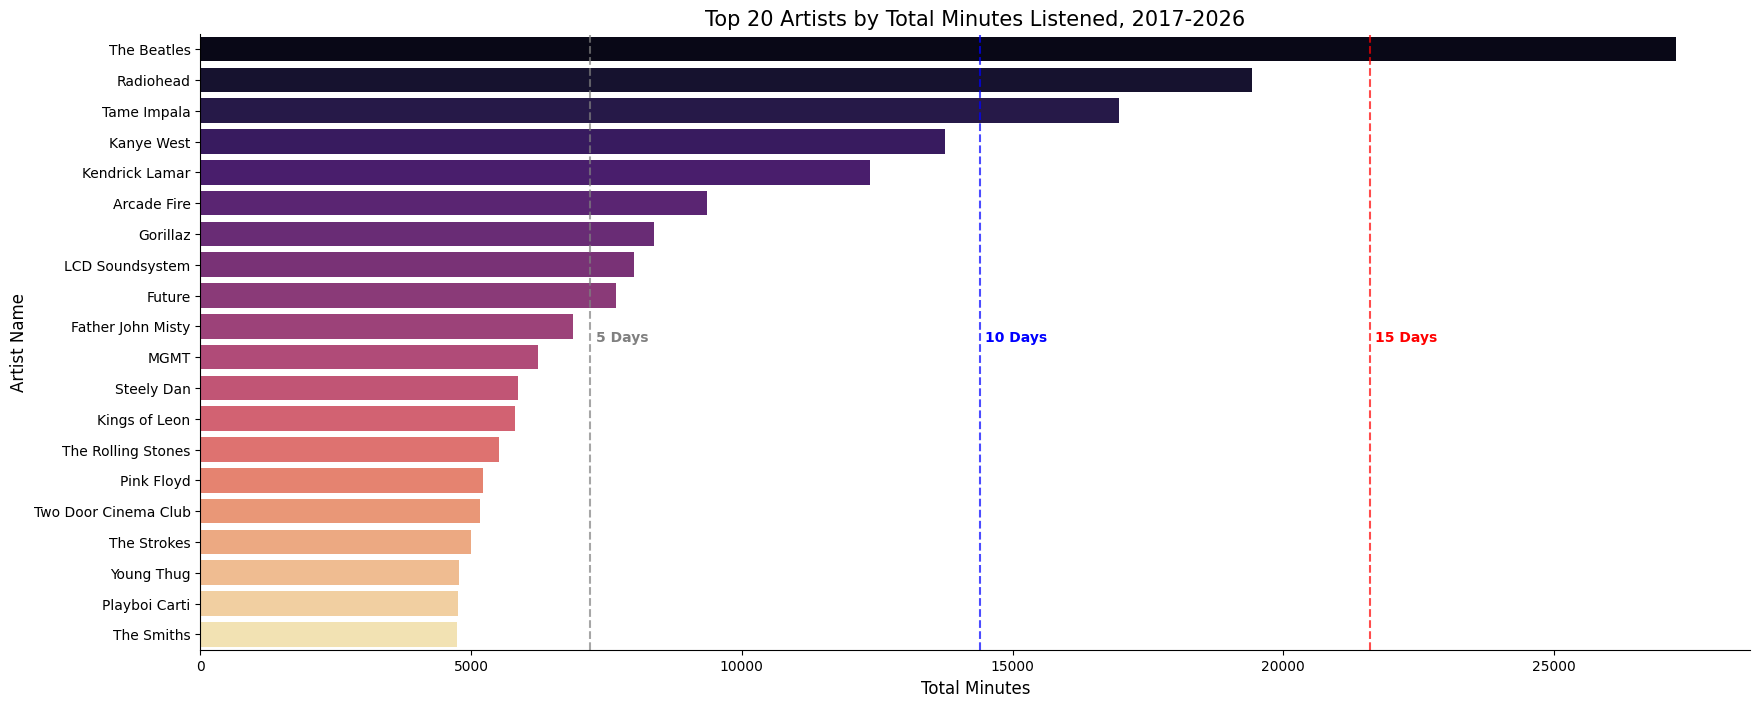

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(x=top_20_minutes.values, y=top_20_minutes.index, hue=top_20_minutes.index, palette='magma')
days_to_plot = [5, 10, 15]
minutes_per_day = 1440
colors = ['gray', 'blue', 'red']
for i, day in enumerate(days_to_plot):
  minute_val = day * minutes_per_day
  if top_20_minutes.max() > minute_val:
    plt.axvline(x=minute_val, color=colors[i], linestyle='--', alpha=0.7)
    plt.text(minute_val + 100, 9.5, f'{day} Days', color=colors[i], fontweight='bold')
plt.title('Top 20 Artists by Total Minutes Listened, 2017-2026', fontsize=15)
plt.xlabel('Total Minutes', fontsize=12)
plt.ylabel("Artist Name", fontsize=12)
sns.despine()
plt.show()

Here I created a chat graph on artsist I've listened to the most. I used axv line to compare it to days, which I found very helpful.

/tmp/ipykernel_3141/4088590057.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_counts.values, y=top_20_counts.index, palette='magma')


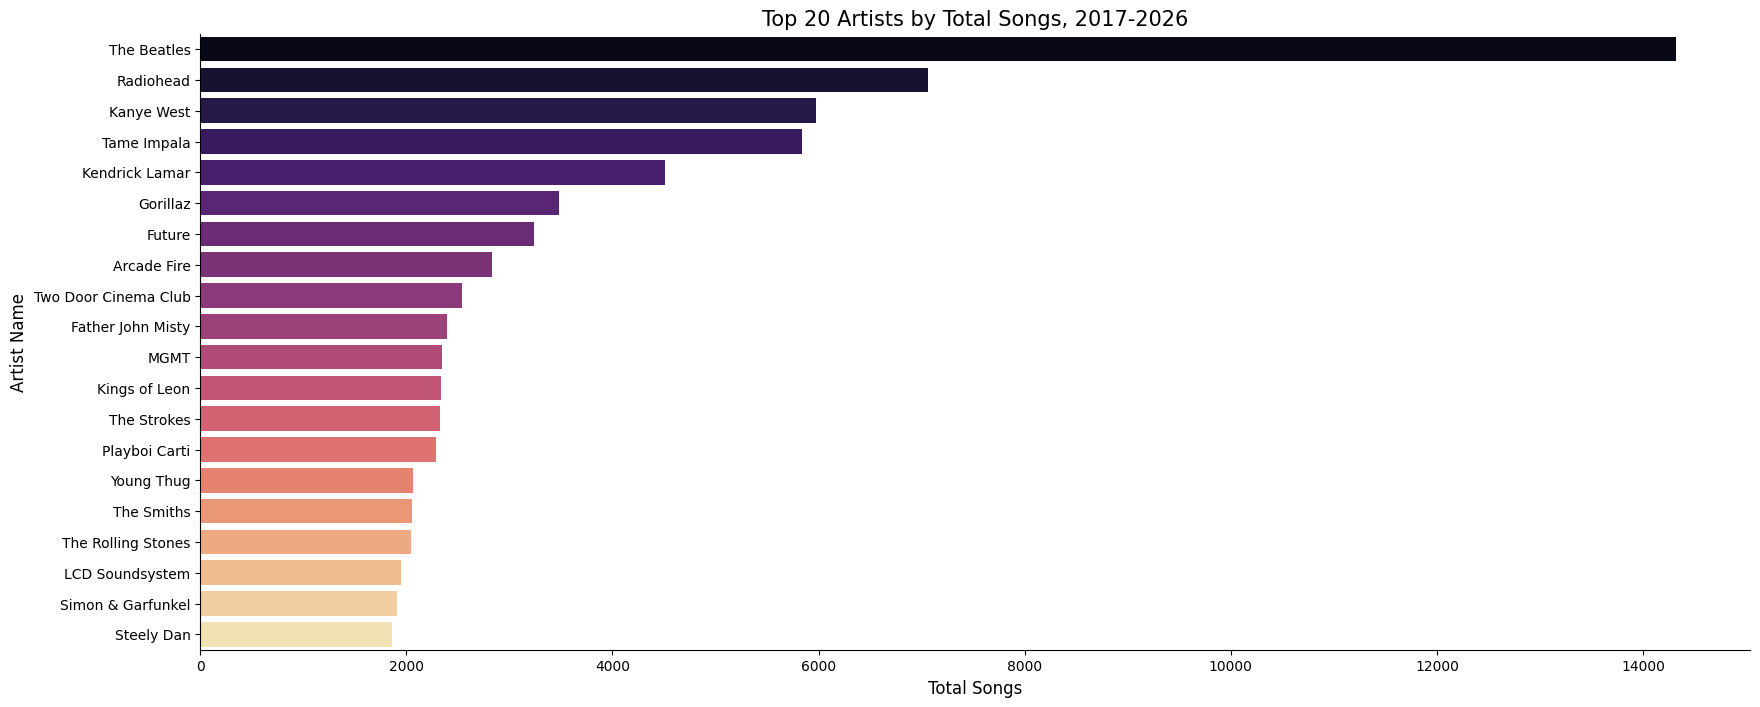

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(x=top_20_counts.values, y=top_20_counts.index, palette='magma')

plt.title('Top 20 Artists by Total Songs, 2017-2026', fontsize=15)
plt.xlabel('Total Songs', fontsize=12)
plt.ylabel("Artist Name", fontsize=12)
sns.despine()
plt.show()

Here I did on pure count, so the amount of total songs listened to for each artist.

Going to make charts for the most listened to albums now.

In [ ]:
df_music['ts'] = pd.to_datetime(df_music['ts']).dt.tz_convert('America/Chicago')

Made sure to convert the time to Chicagoan.

In [ ]:
rename_dict = {
    'master_metadata_album_artist_name': 'artist',
    'master_metadata_album_album_name': 'album',
    'master_metadata_track_name': 'song'
}
df_music = df_music.rename(columns=rename_dict)
print(df_music.columns)

Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr', 'song',
       'artist', 'album', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode', 'minutes_played', 'hour', 'day',
       'month', 'year', 'season'],
      dtype='object')


I renamed the dictionary here so coding was easier, writing master metadata every time was unecessarily difficult.

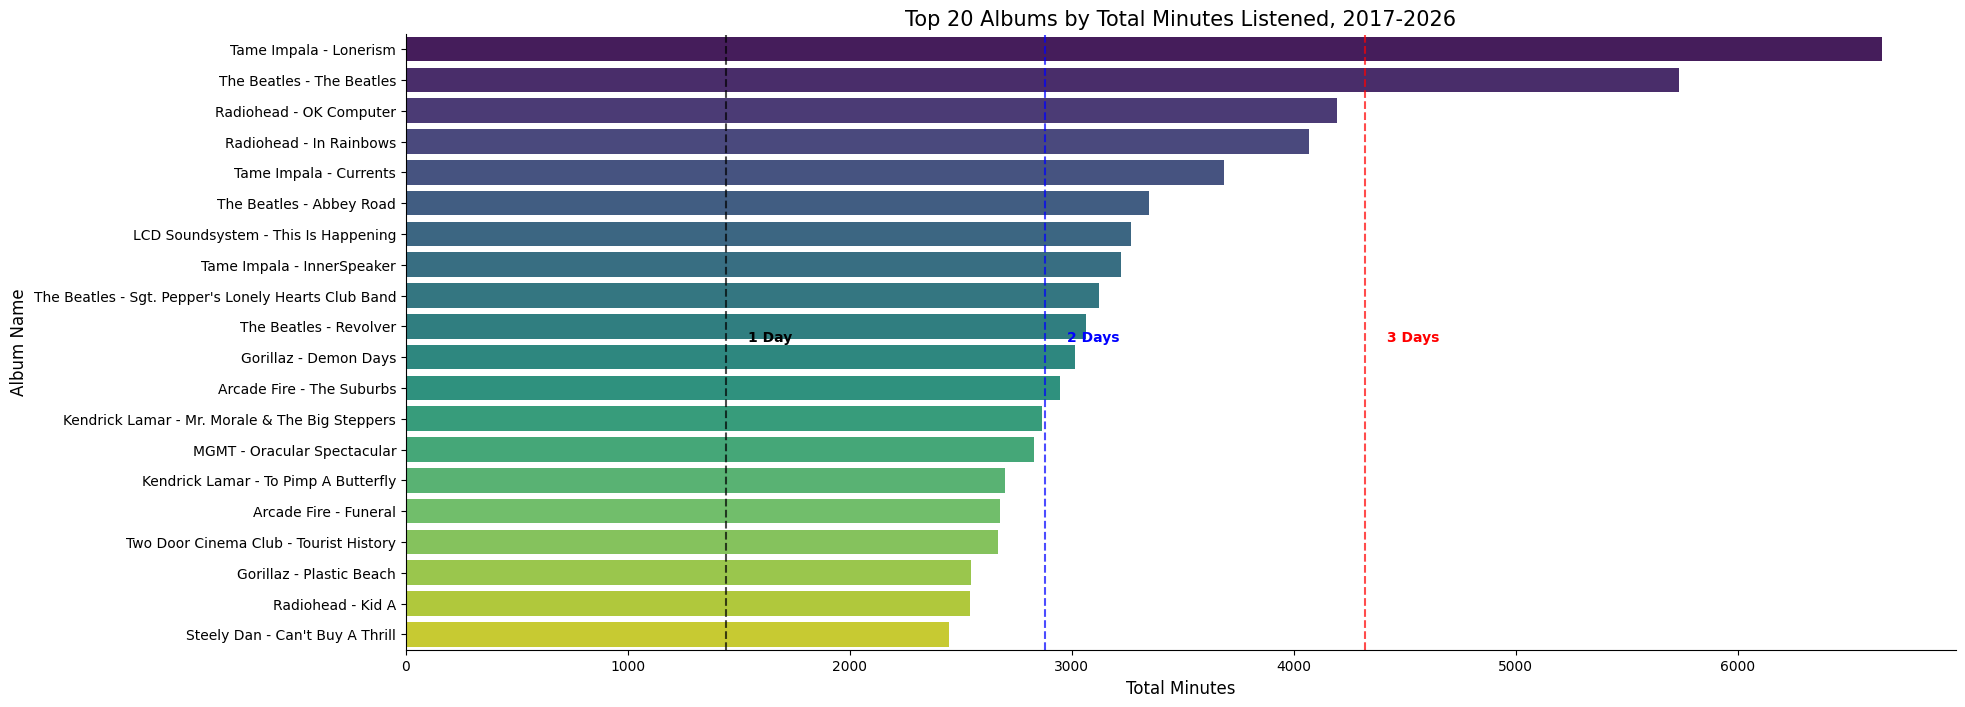

In [ ]:
top_20_albums = df_music.groupby(['artist', 'album'])['minutes_played'].sum().sort_values(ascending=False).head(20)
album_labels = [f"{a} - {al}" for a, al in top_20_albums.index]
plt.figure(figsize=(20,8))
sns.barplot(x=top_20_albums.values, y=album_labels, hue=album_labels, palette='viridis', legend=False)
days_to_plot = [1, 2, 3]
minutes_per_day = 1440
colors = ['black', 'blue', 'red']
for i, day in enumerate(days_to_plot):
  minute_val = day * minutes_per_day
  if top_20_minutes.max() > minute_val:
    plt.axvline(x=minute_val, color=colors[i], linestyle='--', alpha=0.7)
    label = "Day" if day == 1 else "Days"
    plt.text(minute_val + 100, 9.5, f'{day} {label}', color=colors[i], fontweight='bold')
plt.title('Top 20 Albums by Total Minutes Listened, 2017-2026', fontsize=15)
plt.xlabel('Total Minutes', fontsize=12)
plt.ylabel("Album Name", fontsize=12)
sns.despine()
plt.show()

Basically copied the code from above, but replaced artist with albums.

Now I'm doing a barchart on songs, will probably look at pre highschool, highschool, and college.

In [ ]:
hs_start = '2019-08-01'
hs_end = '2023-08-01'
df_hs = df_music[(df_music['ts'] >= hs_start) & (df_music['ts'] < hs_end)].copy()
df_college = df_music[df_music['ts'] >= hs_end].copy()
df_total = df_music.copy()

def plot_top_songs(df, title_period, metric='count'):
  df['song_identity'] = df['song'] + " (" + df['artist'] + ")"

  if metric == 'count':
    data = df['song_identity'].value_counts().head(20)
    xlabel = 'Number of Plays'
    color_map = 'viridis'
  else:
    data = df.groupby('song_identity')['ms_played'].sum().div(60000).sort_values(ascending=False).head(20)
    xlabel = 'Total Minutes Listened'
    color_map = 'magma'
  plt.figure(figsize=(20,8))
  sns.barplot(x=data.values, y=data.index, palette=color_map)
  plt.title(f'Top 20 Songs: {title_period} ({xlabel})', fontsize=16)
  plt.xlabel(xlabel, fontsize=12)
  plt.ylabel('Song', fontsize=12)
  plt.tight_layout()
  plt.show()

For songs here I wanted to make many so I created a function with teh ability to show count, total minutes, highschool, college, and total depending on what I wanted to see. I used ms because I forgot I coded minutes in haha.

/tmp/ipykernel_3141/3734047269.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=color_map)


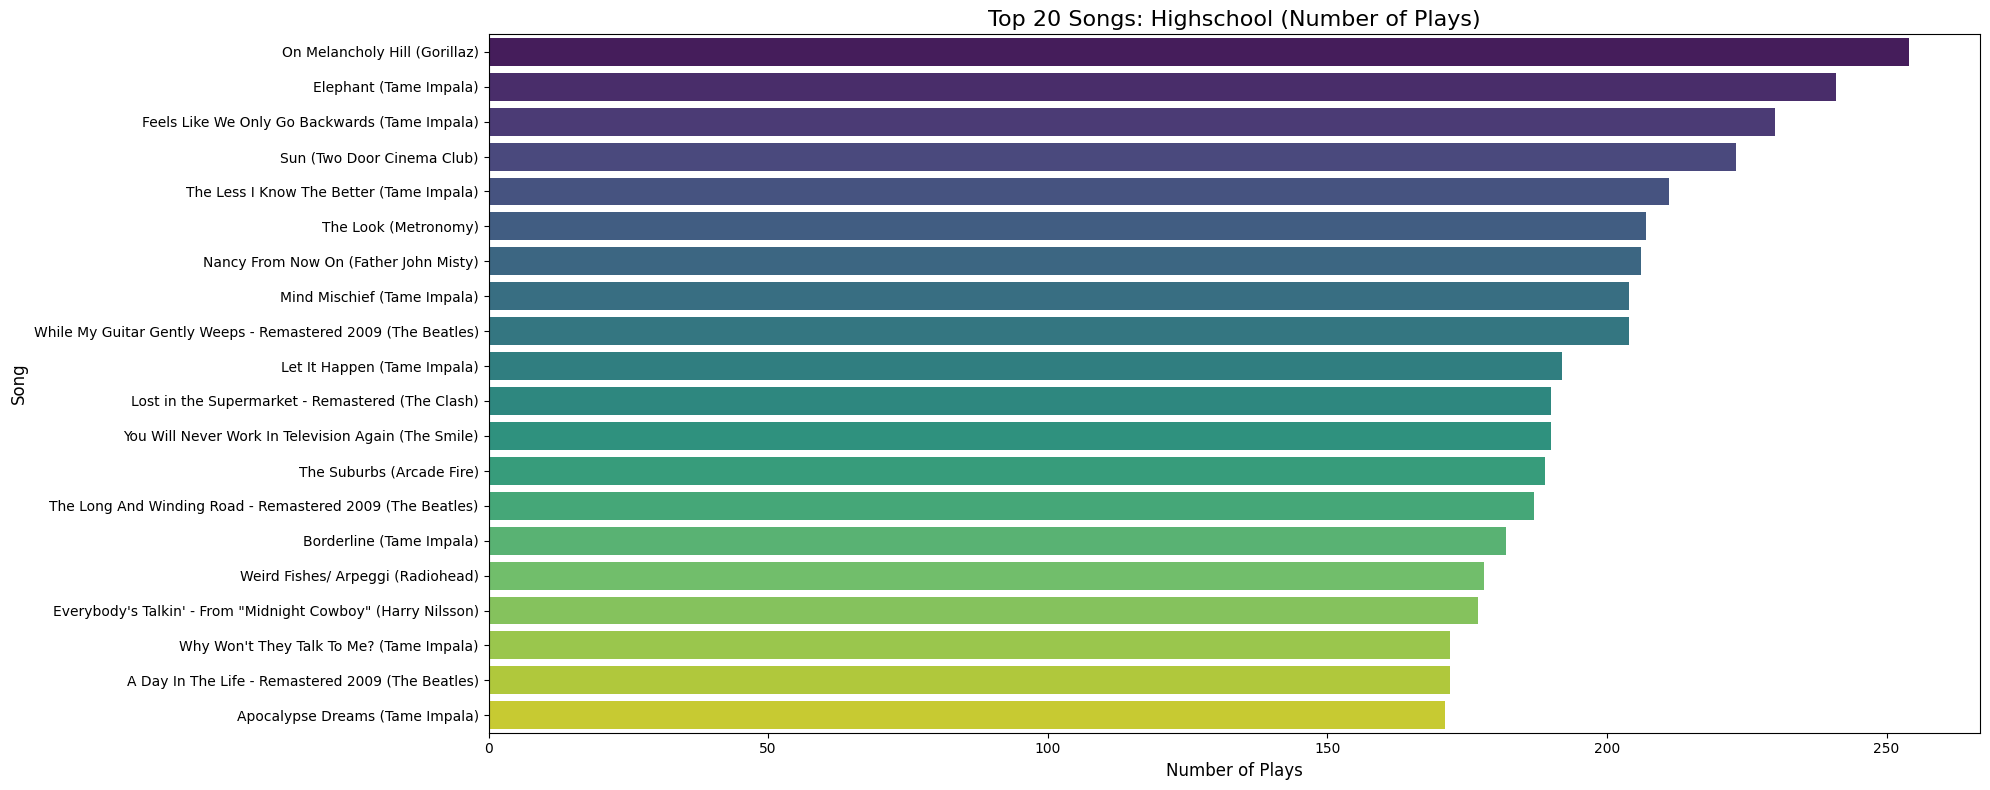

In [ ]:
plot_top_songs(df_hs, 'Highschool')

/tmp/ipykernel_3141/3734047269.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=color_map)


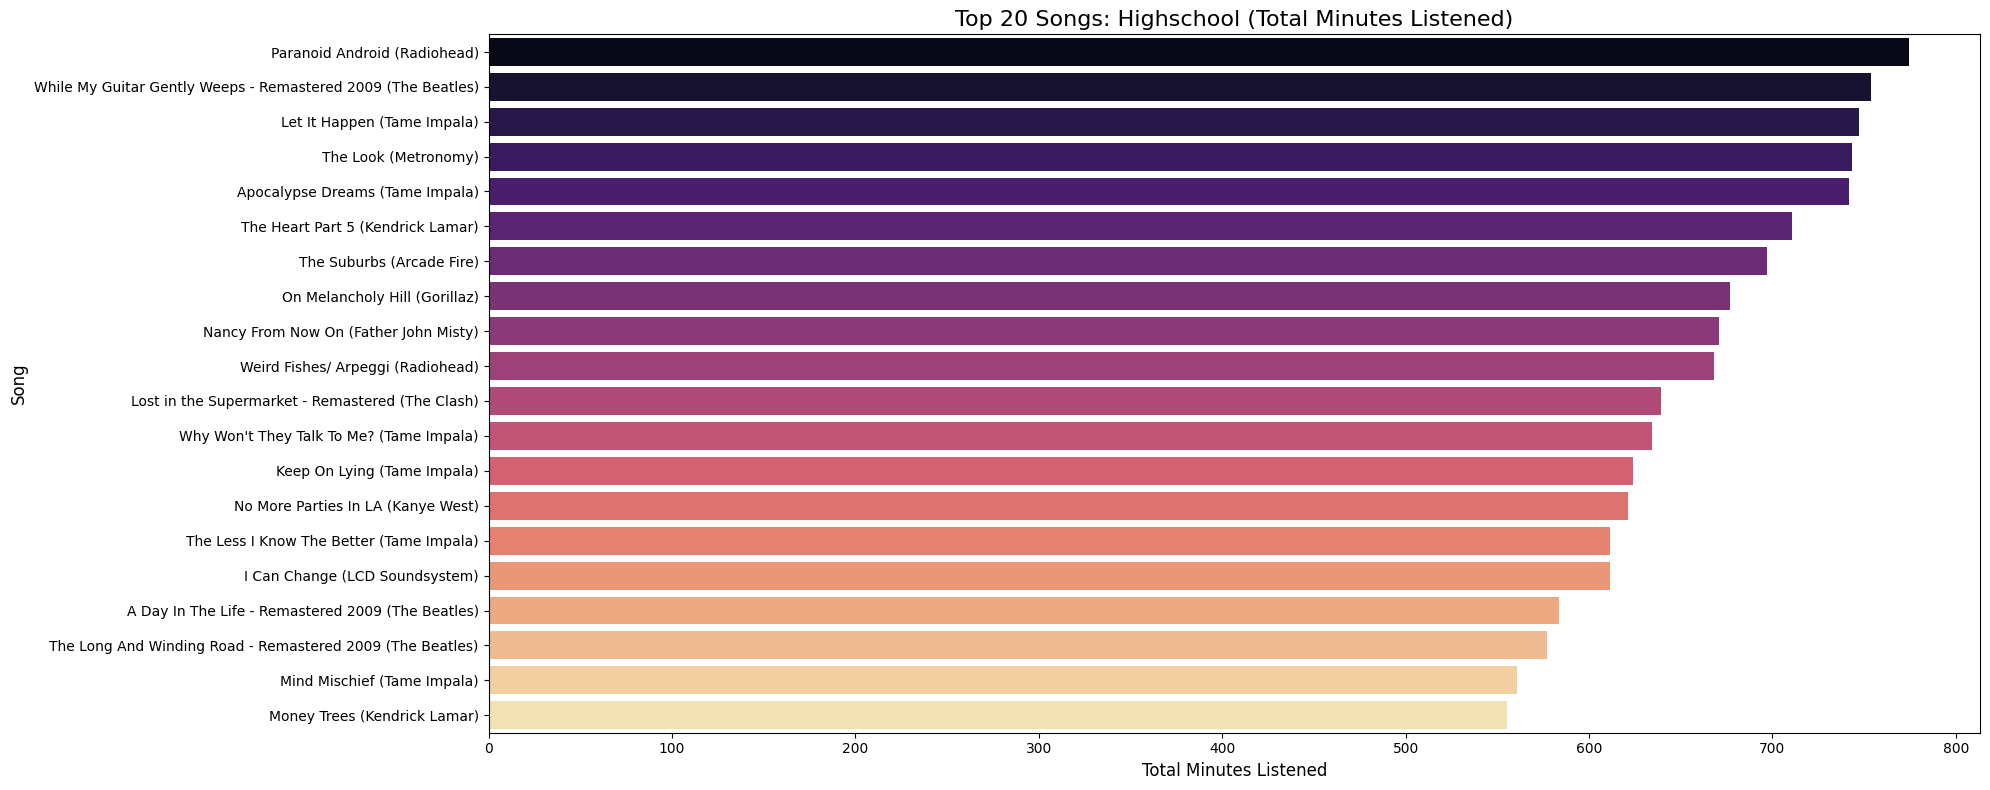

In [ ]:
plot_top_songs(df_hs, 'Highschool', metric='minutes')

/tmp/ipykernel_3141/3734047269.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=color_map)


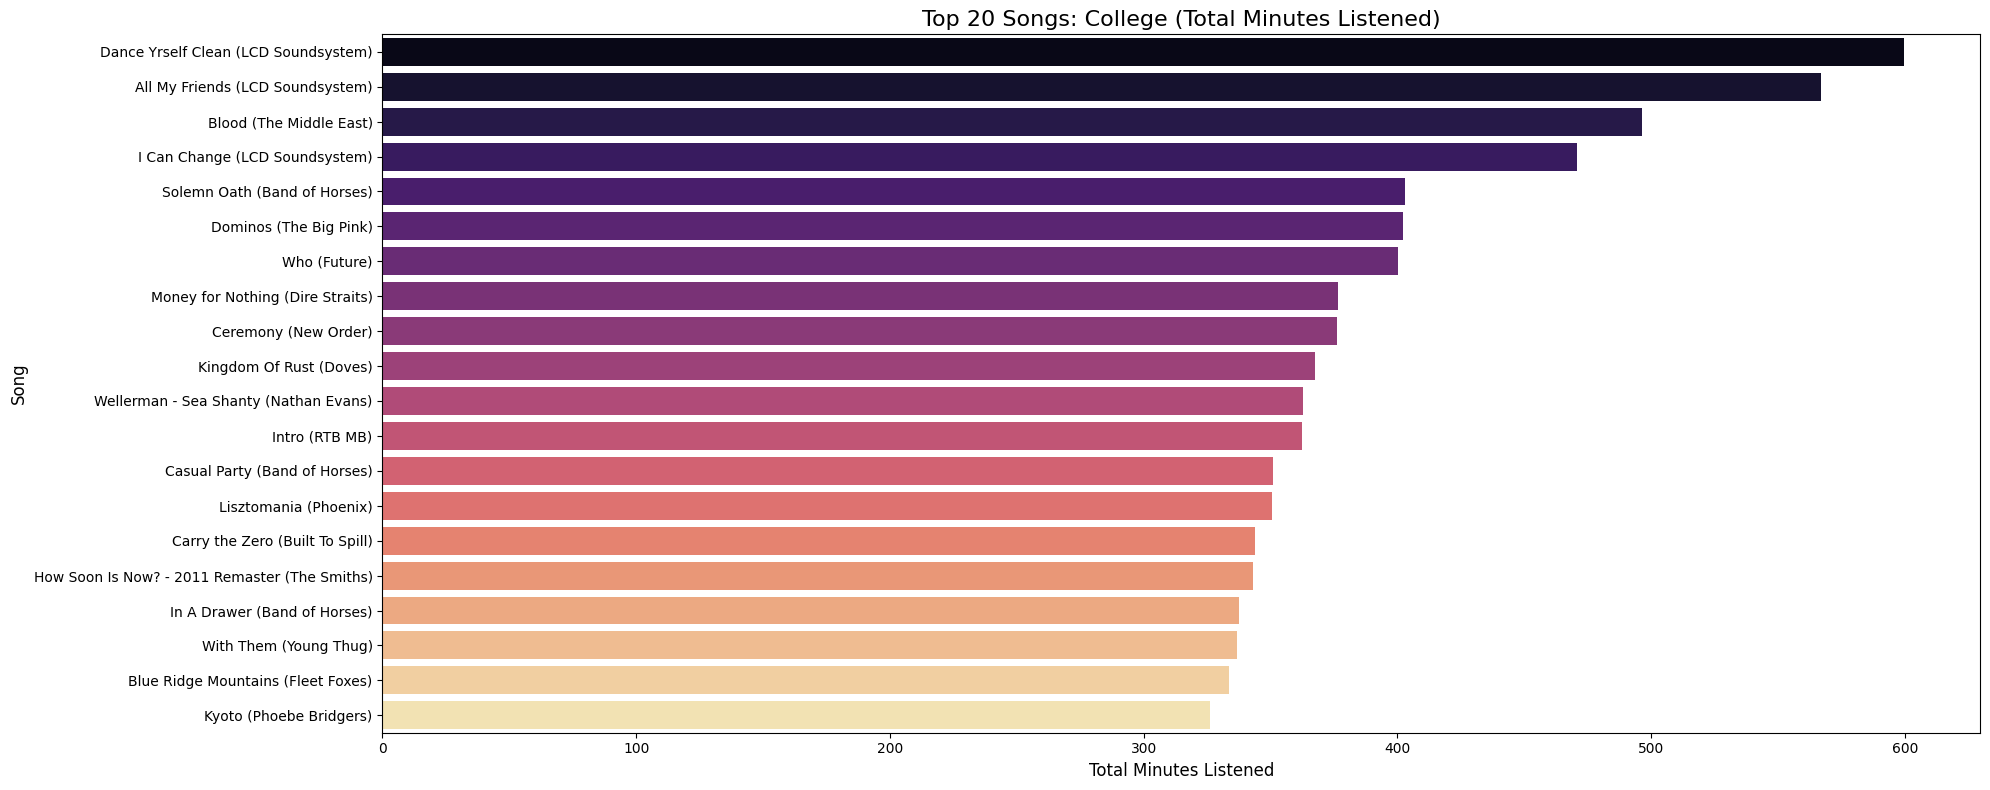

In [ ]:
plot_top_songs(df_college, 'College', metric='Count')

/tmp/ipykernel_3141/3734047269.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=color_map)


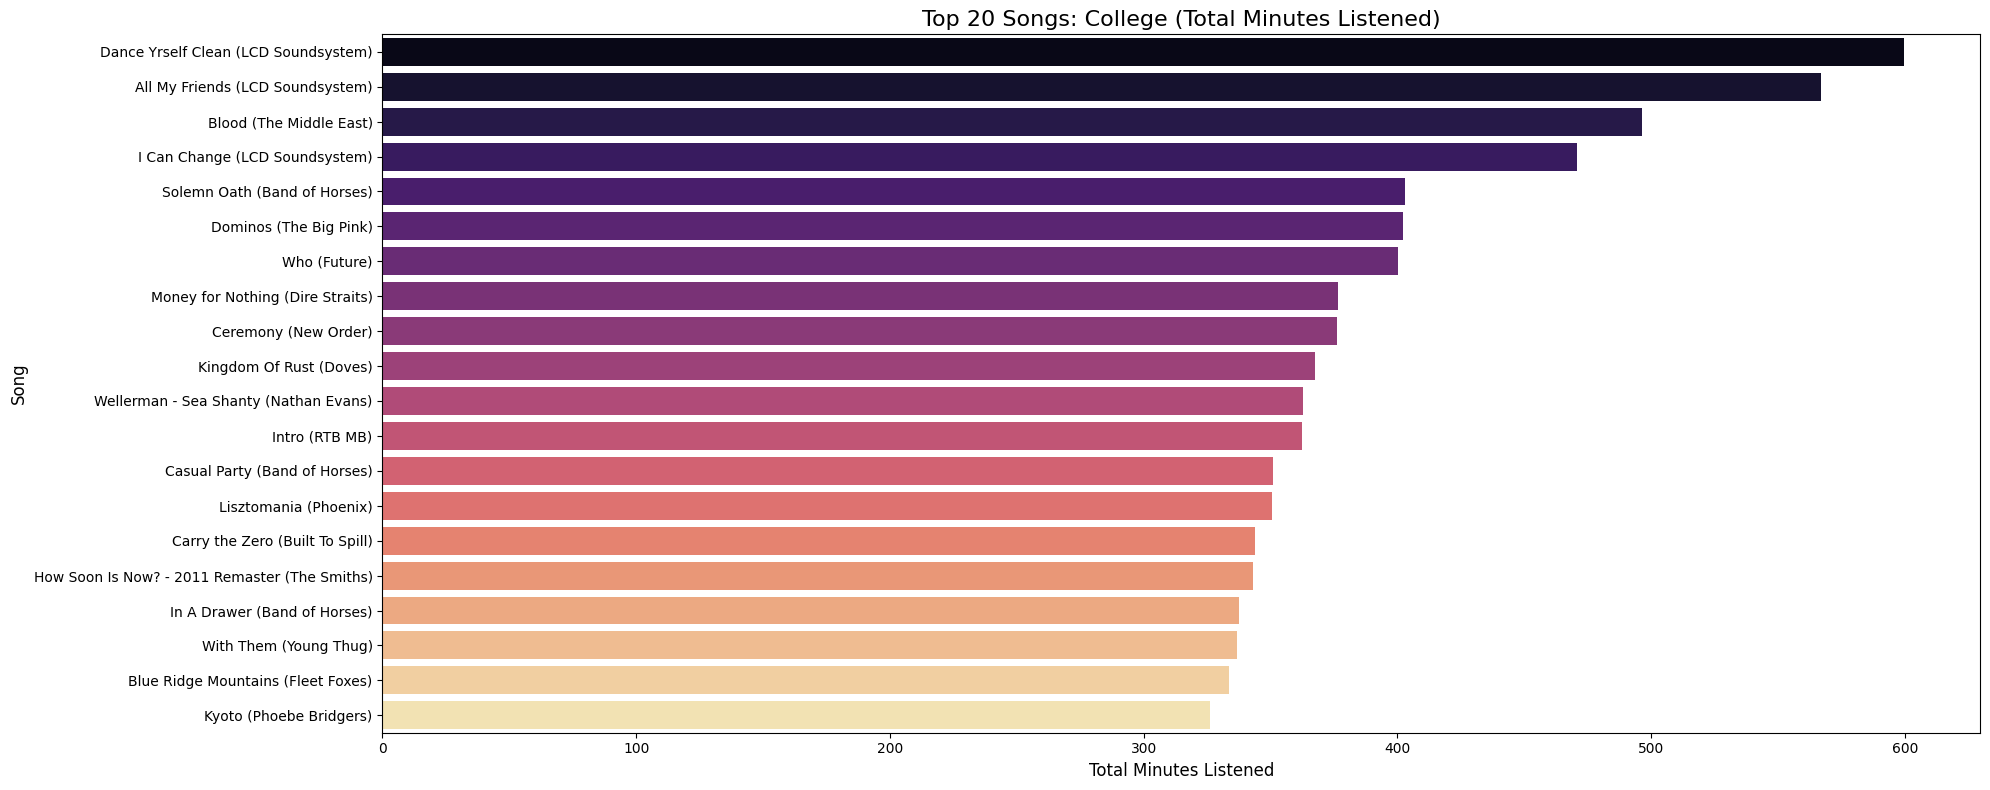

In [ ]:
plot_top_songs(df_college, 'College', metric='minutes')

/tmp/ipykernel_3141/3734047269.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=color_map)


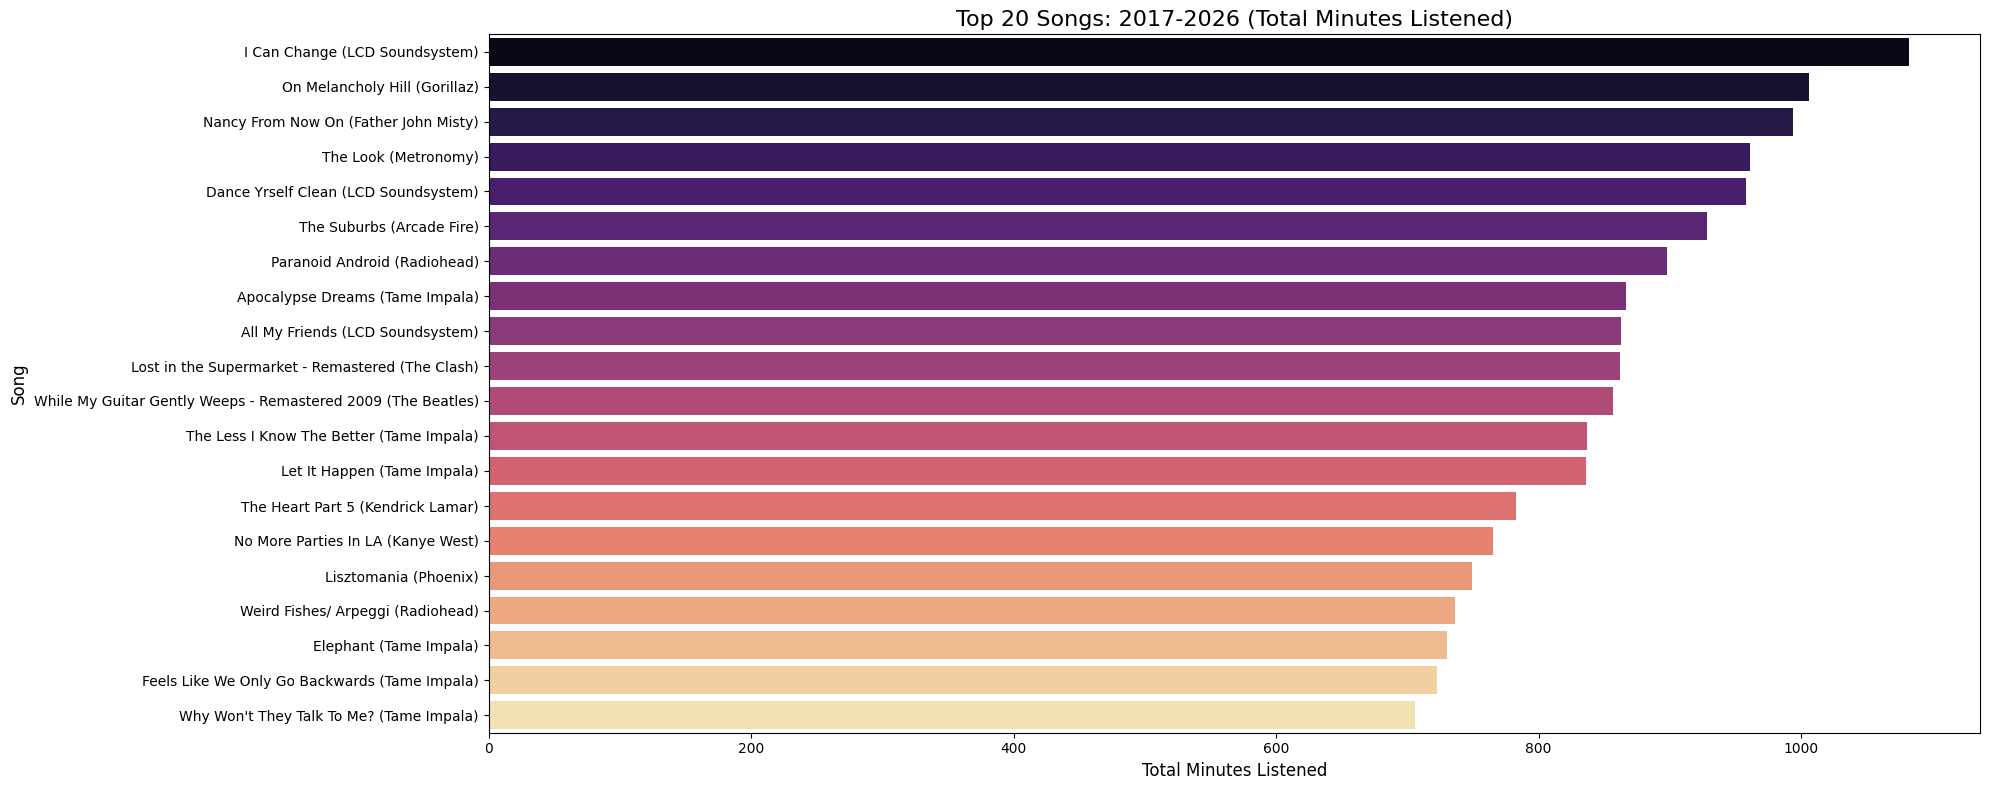

In [ ]:
plot_top_songs(df_music, '2017-2026', metric='Count')

/tmp/ipykernel_3141/3734047269.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=color_map)


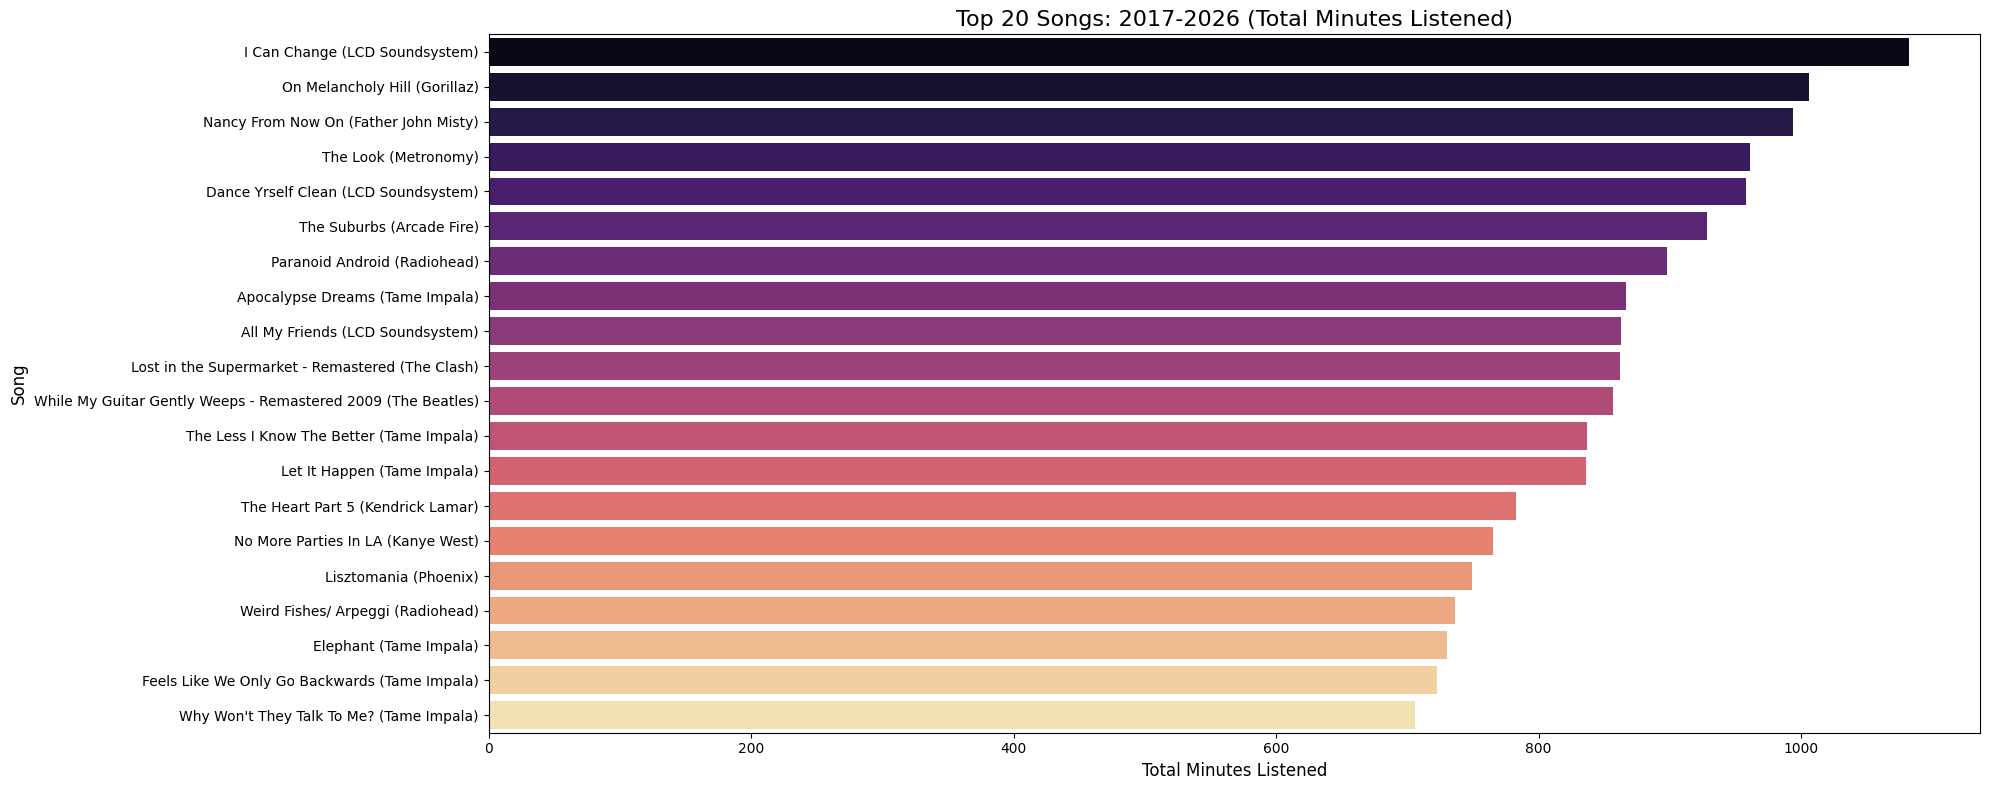

In [ ]:
plot_top_songs(df_music, '2017-2026', metric='minutes')

Very cool data! This one totally surprised me. I assumed the Beatles would be in my top 20 but it shows that I listen to albums and playlists for them, not singular songs.

No I'm doing a heatmap for how much i listen to per hour of the day and day of the week.

In [ ]:
df_music['ts'] = pd.to_datetime(df_music['ts']).dt.tz_convert('America/Chicago')


df_music['hour'] = df_music['ts'].dt.hour
df_music['day_name'] = df_music['ts'].dt.day_name()

This is very important, after coverting tiem to chicago, I had to make sure hours and days were converted as well under the new timezone..

In [ ]:
hs_start = '2019-08-01'
hs_end = '2023-08-01'
df_hs = df_music[(df_music['ts'] >= hs_start) & (df_music['ts'] < hs_end)]
df_college = df_music[df_music['ts'] >= hs_end]

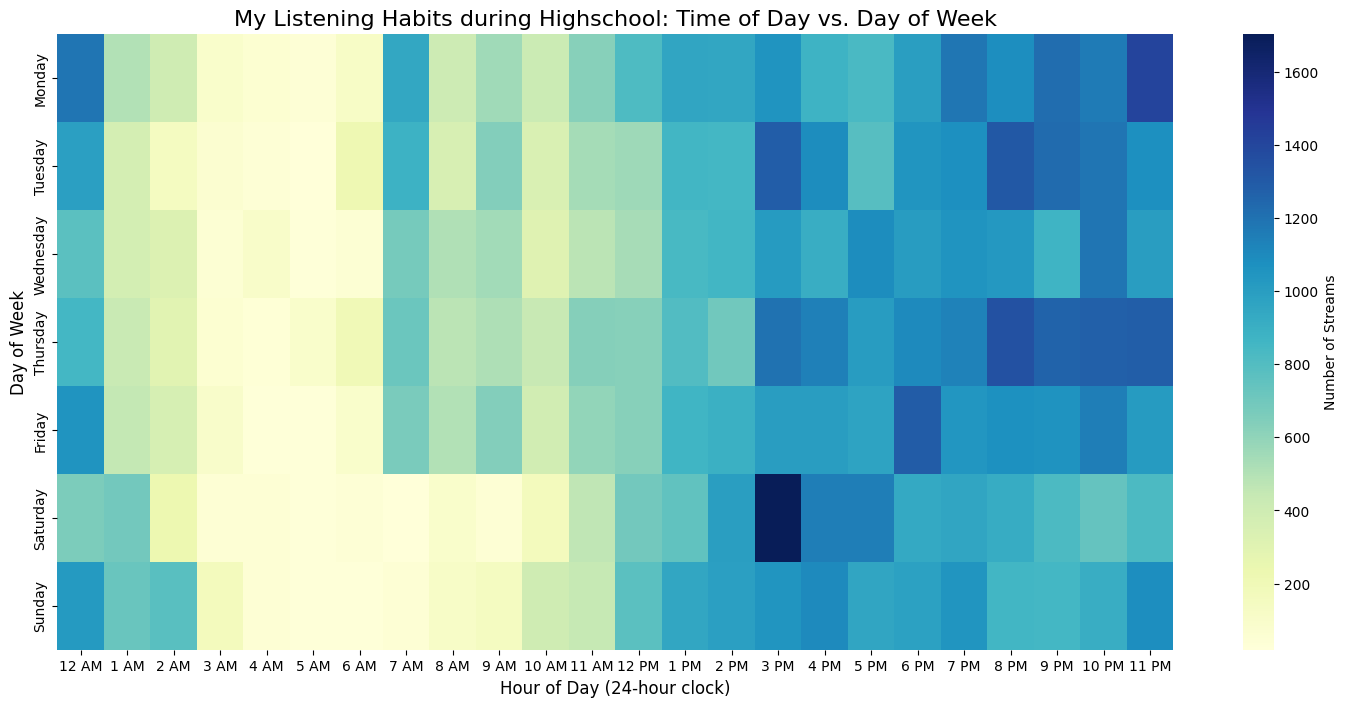

In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hour_labels = [
    "12 AM", "1 AM", "2 AM", "3 AM", "4 AM", "5 AM", "6 AM", "7 AM", "8 AM", "9 AM", "10 AM", "11 AM",
    "12 PM", "1 PM", "2 PM", "3 PM", "4 PM", "5 PM", "6 PM", "7 PM", "8 PM", "9 PM", "10 PM", "11 PM"
]
heatmap_data = pd.crosstab(df_hs['day'], df_hs['hour'])
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Number of Streams'}, xticklabels=hour_labels)

plt.title('My Listening Habits during Highschool: Time of Day vs. Day of Week', fontsize=16)
plt.xlabel('Hour of Day (24-hour clock)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

plt.show()

It shows I listen pretty regularly throughout the day, but more towards the afternoon/evening. The coolest thing is it shows my sleep schedule very well.

Now I'm doing the same thing but for college.

In [ ]:
df_music['ts'] = pd.to_datetime(df_music['ts']).dt.tz_convert('America/New_York')


df_music['hour'] = df_music['ts'].dt.hour
df_music['day_name'] = df_music['ts'].dt.day_name()

Used new york because I'm in New York for college. Unfortunately, summers and my time here at london aren't counted but those affects are so marginal I don't think it mattered. Also, I listen to way less music here in London and during the summer.

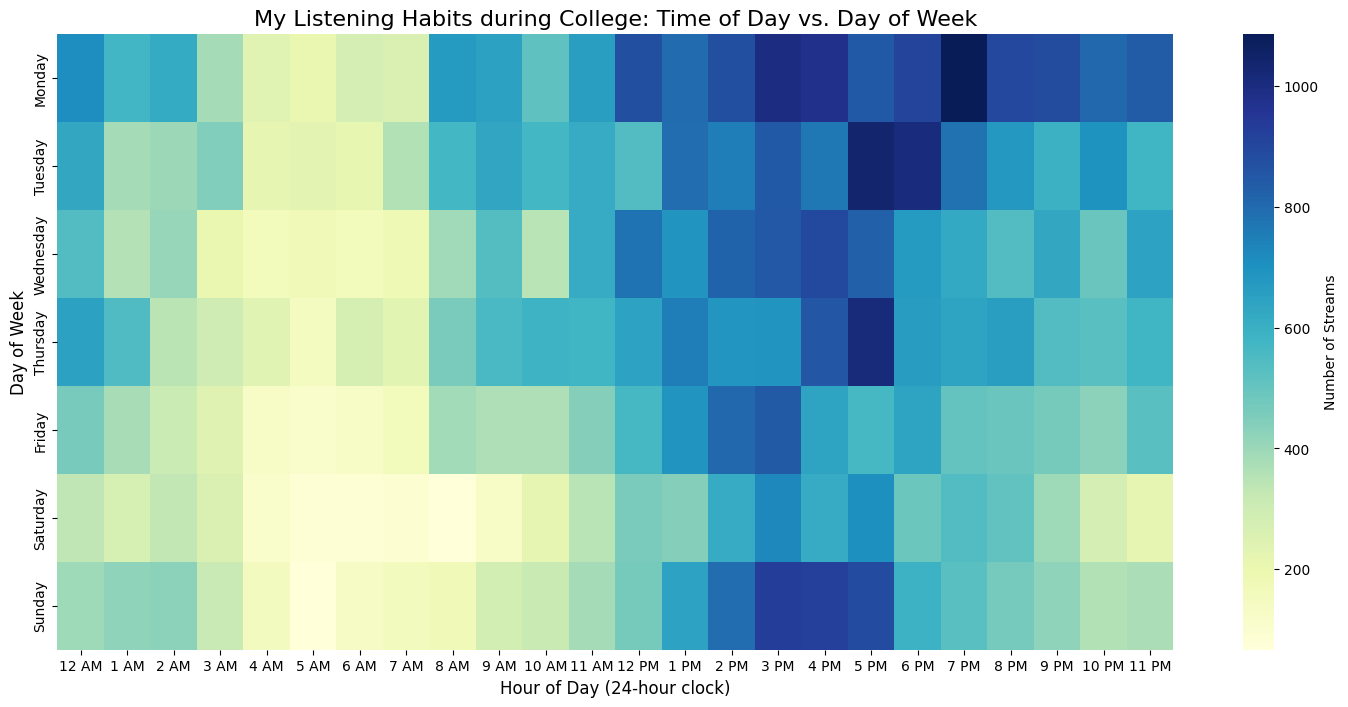

In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hour_labels = [
    "12 AM", "1 AM", "2 AM", "3 AM", "4 AM", "5 AM", "6 AM", "7 AM", "8 AM", "9 AM", "10 AM", "11 AM",
    "12 PM", "1 PM", "2 PM", "3 PM", "4 PM", "5 PM", "6 PM", "7 PM", "8 PM", "9 PM", "10 PM", "11 PM"
]
heatmap_data = pd.crosstab(df_college['day'], df_college['hour'])
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Number of Streams'}, xticklabels=hour_labels)

plt.title('My Listening Habits during College: Time of Day vs. Day of Week', fontsize=16)
plt.xlabel('Hour of Day (24-hour clock)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

plt.show()

Obviously, sleep schedule is very messy here which is in line with what I know about myself. I'm doing a lot of homework at 2 am on Monday!

Now I'm going to do a log regression of time of day with skip of song

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

df_music['skip'] = (df_music['skipped'] == True ).astype(int)
df_music['shuffle'] = (df_music['shuffle'] == True ).astype(int)
df_ml = df_music.copy()
df_ml['month'] = df_ml['ts'].dt.month
df_ml['day_of_week'] = df_ml['ts'].dt.dayofweek
df_ml['hour'] = df_ml['ts'].dt.hour

X = df_ml[['season', 'day_of_week', 'shuffle', 'hour']]
X = pd.get_dummies(X, columns=['season', 'day_of_week', 'hour'], drop_first=True)
y = df_ml['skip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


This test was interesting but honestly not justified. I tried to predict whether I skip songs based on time of the day/season/year/shuffle but it really didn't work. I don't think I work that way. Sometiems I'll leave the music going in teh background for hours or I'll skip a million songs at once.

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred): 2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:  0.557631

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.56      0.67     32932
           1       0.23      0.53      0.32      8018

    accuracy                           0.56     40950
   macro avg       0.53      0.55      0.50     40950
weighted avg       0.71      0.56      0.60     40950



Here we see a lot of precission on Not Skip but not on Skip. Why? It's because there's bias from the sheer amount of not skips I have. I reduced this slightly with making teh classes balanced but my heart really wasn't in this one.

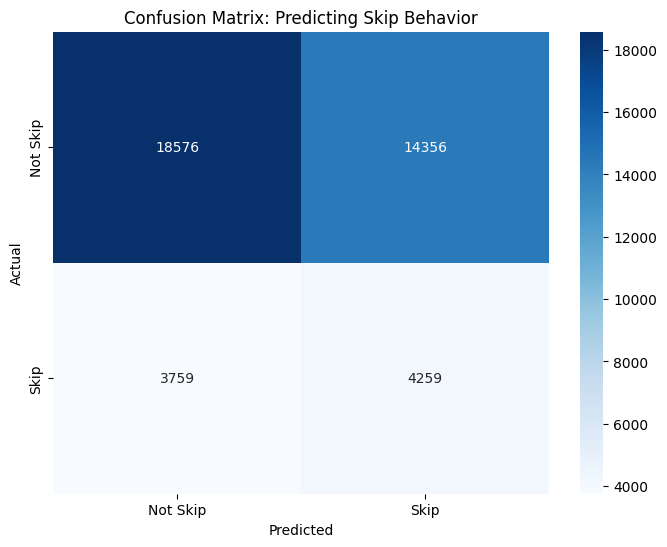

In [ ]:
labels = ['Not Skip', 'Skip']
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix: Predicting Skip Behavior")
plt.show()

In [ ]:
feature_names = X.columns
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance.head(10))
print(feature_importance.tail(10))

    Feature  Importance
10   hour_4    0.926066
12   hour_6    0.888197
13   hour_7    0.726298
11   hour_5    0.679640
15   hour_9    0.591765
17  hour_11    0.474370
19  hour_13    0.433061
9    hour_3    0.404935
18  hour_12    0.398432
21  hour_15    0.387038
          Feature  Importance
6   day_of_week_6    0.007348
28        hour_22    0.001406
14         hour_8   -0.010474
1   day_of_week_1   -0.025264
29        hour_23   -0.042969
27        hour_21   -0.062842
3   day_of_week_3   -0.073088
4   day_of_week_4   -0.123122
2   day_of_week_2   -0.140681
5   day_of_week_5   -0.231913


This is pretty interesting. Obviously, the hours I'm not listening will be pretty indicative as hours 4, 6, and 7 show. Day of week had little tio no affect.

going to see if I can call API! This was an absolute tragedy. As I laid out in my presentation, I spent a whole day on this. I had to find out how to call the Spotify API and then I had to see how I could call it without it shutting me out.

In [ ]:
num_unique_artists = df_music['artist'].nunique()
print(num_unique_artists)
x = (3895 * 1.1)/60
print(x)
print(df_music['artist'].value_counts().head(550))

3895
71.40833333333333
artist
The Beatles       14325
Radiohead          7058
Kanye West         5973
Tame Impala        5839
Kendrick Lamar     4511
                  ...  
Flea                 32
Carly Simon          32
Metric               32
The Fratellis        32
Day Wave             32
Name: count, Length: 550, dtype: int64


In [ ]:
import time
import json
from tqdm import tqdm

In [ ]:
unique_artists = df_music['artist'].unique()
artist_genres = {}

In [ ]:
try:
  with open('genre_cache.json', 'r') as f:
    artist_genres = json.load(f)
except FileNotFoundError:
  artist_genres = {}
print(len(unique_artists))
print(len(artist_genres))

3895
0


In [ ]:
for artist in tqdm(unique_artists):
  if artist in artist_genres:
    continue
  try:
    results = sp.search(q='artist:' + artist, type='artist', limit=1)
    items = results['artists']['items']
    if len(items) > 0:
      # Use .get() to safely access 'genres' key, defaulting to an empty list
      artist_genres[artist] = items[0].get('genres', [])
    else:
      artist_genres[artist] = []
    time.sleep(1.1)

    # Save to cache periodically
    if len(artist_genres) % 10 == 0:
      with open('genre_cache.json', 'w') as f: # Corrected filename here
        json.dump(artist_genres, f)
  except Exception as e:
    print(f"Error fetching genres for {artist}: {e}")
    # Always save cache on error before breaking to preserve progress
    with open('genre_cache.json', 'w') as f:
      json.dump(artist_genres, f)
    break
# After the loop, save the final state of the cache
with open('genre_cache.json', 'w') as f:
  json.dump(artist_genres, f)

  0%|          | 0/3895 [00:19<?, ?it/s]


KeyboardInterrupt: 

It would tell me that I had to come back in 24 hours to reuse the API. I tried to increase the interval between each call of the API and reduce the number of artists that actually ran, but when I looked at my new dictionary, there was no genres input! After screaming and crying, I ended up using ChatGPT. I am sad about it, however. If I could have gotten vectorized information on each song like valence or energy, I could ahve done someting very cool with it. My roommate once told me all the songs I listen to have a similar melancholy feel. I wish I could have proved that or disputed that with data but I still managed to do a cool analysis with K-Means Clusters.

I can't. I will instead use a LLM to input spotify-like genres into all my different

Gonna look through data for genres now.

In [ ]:
artist_ranking = df_music.groupby('artist')['ms_played'].sum().reset_index()
artist_ranking = artist_ranking.sort_values(by='ms_played', ascending=False)
top_500_names = artist_ranking['artist'].head(500).tolist()

with open('top_500_artists.txt', 'w') as f:
  for name in top_500_names:
    f.write(f"{name}\n")


NameError: name 'df_music' is not defined

This was very interesting. I used ChatGPT to input the top 500 artists I had because I knew any more would give me some issues liek increasing teh chances of hallucination (Taylor Swift is not a "Chicago Rap" artist!).

In [ ]:

top_500_genres = {

    "The Beatles": ["british invasion", "classic rock", "rock"],
    "Radiohead": ["art rock", "oxford indie", "permanent wave"],
    "Tame Impala": ["australian psych", "neo-psychedelia", "psychedelic pop"],
    "Kanye West": ["chicago rap", "hip hop", "rap"],
    "Kendrick Lamar": ["conscious hip hop", "hip hop", "rap"],
    "Arcade Fire": ["baroque pop", "indie rock", "modern rock"],
    "Gorillaz": ["art pop", "alternative hip hop"],
    "LCD Soundsystem": ["alternative dance", "indietronica", "new york city indie"],
    "Future": ["atl hip hop", "pop rap", "trap"],
    "Father John Misty": ["indie folk", "indie pop", "indie rock"],
    "MGMT": ["indie rock", "indietronica", "neo-psychedelia"],
    "Steely Dan": ["album rock", "classic rock", "mellow gold", "yacht rock"],
    "Kings of Leon": ["modern rock", "indie rock"],
    "The Rolling Stones": ["album rock", "classic rock", "rock"],
    "Pink Floyd": ["art rock", "progressive rock", "psychedelic rock"],
    "Two Door Cinema Club": ["indie pop", "indietronica", "modern rock"],
    "The Strokes": ["garage rock", "indie rock", "post-punk revival"],
    "Young Thug": ["atl hip hop", "melodic rap", "trap"],
    "Playboi Carti": ["atl hip hop", "cloud rap", "trap"],
    "The Smiths": ["indie rock", "madchester", "post-punk"],
    "Simon & Garfunkel": ["classic rock", "folk", "folk rock"],
    "Fleet Foxes": ["chamber pop", "indie folk", "stomp and holler"],
    "Paul Simon": ["classic rock", "folk rock", "mellow gold"],
    "Big Thief": ["brooklyn indie", "indie rock"],
    "Band of Horses": ["indie folk", "indie rock", "modern rock"],
    "Sufjan Stevens": ["baroque pop", "indie folk", "indie pop"],
    "Coldplay": ["permanent wave", "pop"],
    "Elton John": ["glam rock", "mellow gold", "piano rock"],
    "Interpol": ["indie rock", "post-punk revival"],
    "Phoenix": ["indie pop", "indietronica"],
    "Wilco": ["alternative rock", "art rock", "indie rock"],
    "The Beach Boys": ["baroque pop", "classic rock", "psychedelic rock"],
    "Travis Scott": ["hip hop", "rap"],
    "Metronomy": ["art pop", "indie pop", "indietronica"],
    "Elliott Smith": ["alternative rock", "indie rock"],
    "The Clash": ["classic rock", "punk", "rock"],
    "Animal Collective": ["experimental pop", "indie rock", "neo-psychedelia"],
    "The Police": ["classic rock", "new wave", "rock"],
    "Fleetwood Mac": ["album rock", "classic rock", "mellow gold", "soft rock"],
    "New Order": ["alternative dance", "new wave", "synthpop"],
    "LUCKI": ["chicago rap", "trap"],
    "Nirvana": ["grunge", "rock"],
    "Joy Division": ["post-punk"],
    "George Harrison": ["album rock", "classic rock"],
    "JPEGMAFIA": ["alternative hip hop", "experimental hip hop"],
    "Nick Mulvey": ["indie folk", "indie soul"],
    "The Cure": ["dance rock", "new wave", "post-punk"],
    "Doves": ["britpop", "indie rock", "madchester"],
    "Passion Pit": ["indie pop", "indietronica"],
    "The Smile": ["art rock", "indie rock"],
    "The Maccabees": ["indie rock", "modern rock"],
    "Daft Punk": ["electro", "filter house"],
    "Paul McCartney": ["album rock", "classic rock"],
    "Bob Dylan": ["album rock", "classic rock", "folk", "folk rock"],
    "Red Hot Chili Peppers": ["alternative rock", "funk rock"],
    "JAY-Z": ["east coast hip hop", "hip hop", "rap"],
    "Stevie Wonder": ["funk", "motown", "soul"],
    "The Bravery": ["indie rock", "new wave revival"],
    "French Kicks": ["indie rock"],
    "The Postal Service": ["indie pop", "indietronica"],
    "Tyler, The Creator": ["hip hop", "rap"],
    "Courtney Barnett": ["australian indie", "indie pop", "indie rock"],
    "The Killers": ["modern rock", "indie rock"],
    "Pond": ["australian psych", "neo-psychedelia"],
    "Vampire Weekend": ["indie pop", "modern rock"],
    "STRFKR": ["indie pop", "indietronica"],
    "Talking Heads": ["art punk", "new wave", "post-punk"],
    "Hans Zimmer": ["orchestral soundtrack", "soundtrack"],
    "Eagles": ["album rock", "classic rock", "soft rock"],
    "The Shins": ["indie pop", "indie rock"],
    "Joey Bada$$": ["conscious hip hop", "hip hop", "rap"],
    "U2": ["irish rock", "permanent wave", "rock"],
    "Chief Keef": ["chicago rap", "drill", "trap"],
    "M83": ["indietronica", "metropopolis", "shoegaze"],
    "Car Seat Headrest": ["indie rock", "lo-fi indie"],
    "Hot Chip": ["alternative dance", "indietronica"],
    "Arctic Monkeys": ["garage rock", "indie rock", "modern rock"],
    "Black Country, New Road": ["crank wave", "indie rock"],
    "Summrs": ["cloud rap", "plugg"],
    "Damon Albarn": ["art pop"],
    "Bread": ["mellow gold", "soft rock"],
    "Ryan Adams": ["alternative country", "singer-songwriter"],
    "Alvvays": ["dream pop", "indie pop", "shoegaze"],
    "Marvin Gaye": ["motown", "soul"],
    "Andrew Bird": ["chamber pop", "indie folk", "indie rock"],
    "John Lennon": ["album rock", "classic rock"],
    "Yeah Yeah Yeahs": ["alternative rock", "dance-punk", "indie rock"],
    "Bruce Springsteen": ["album rock", "classic rock", "heartland rock"],
    "Bladee": ["cloud rap", "drain", "hyperpop"],
    "Sun Kil Moon": ["indie folk", "slowcore"],
    "The Head And The Heart": ["folk-pop", "indie folk"],
    "The Replacements": ["alternative rock", "art punk", "indie rock"],
    "The Byrds": ["classic rock", "folk rock", "psychedelic rock"],
    "John Mayer": ["neo-mellow", "pop"],
    "David Bowie": ["art rock", "glam rock", "rock"],
    "The Smashing Pumpkins": ["alternative rock", "grunge"],
    "Night Moves": ["indie pop", "indie rock"],
    "Cage The Elephant": ["modern rock", "indie rock"],
    "Grizzly Bear": ["art pop", "brooklyn indie", "indie folk"],
    "The Flaming Lips": ["alternative rock", "neo-psychedelia"],
    "Jackson Browne": ["album rock", "classic rock", "mellow gold"],


    "The Good, the Bad & the Queen": ["art pop"],
    "Earl Sweatshirt": ["alternative hip hop", "hip hop"],
    "Mac DeMarco": ["indie pop", "lo-fi indie"],
    "The Verve": ["britpop", "madchester"],
    "Broken Bells": ["indie pop", "indie rock"],
    "Metro Boomin": ["hip hop", "rap", "trap"],
    "The Alan Parsons Project": ["album rock", "art rock", "progressive rock"],
    "Michael Jackson": ["pop", "r&b", "soul"],
    "Yusuf / Cat Stevens": ["classic rock", "folk rock"],
    "Pixies": ["alternative rock", "indie rock"],
    "MF DOOM": ["alternative hip hop", "hip hop"],
    "Built To Spill": ["alternative rock", "indie rock"],
    "Don McLean": ["classic rock", "folk rock"],
    "Harry Nilsson": ["baroque pop", "classic rock", "mellow gold"],
    "The Whitest Boy Alive": ["indie pop", "indietronica"],
    "Frank Ocean": ["lgbtq+ hip hop", "neo soul", "pop"],
    "Neutral Milk Hotel": ["anti-folk", "indie folk", "lo-fi indie"],
    "R.E.M.": ["alternative rock", "indie rock", "rock"],
    "Electric Light Orchestra": ["album rock", "symphonic rock"],
    "The Weeknd": ["canadian contemporary r&b", "pop"],
    "Death Cab for Cutie": ["indie pop", "indie rock", "modern rock"],
    "Modest Mouse": ["indie rock", "modern rock"],
    "Phil Collins": ["mellow gold", "soft rock"],
    "Kid Cudi": ["hip hop", "pop rap"],
    "Bloc Party": ["dance-punk", "indie rock", "post-punk revival"],
    "Iron & Wine": ["chamber pop", "indie folk"],
    "Led Zeppelin": ["album rock", "classic rock", "hard rock"],
    "Broken Social Scene": ["canadian indie", "indie rock"],
    "Muse": ["modern rock", "rock"],
    "MJ Lenderman": ["indie rock"],
    "Baby Keem": ["hip hop", "rap"],
    "Bon Iver": ["chamber pop", "indie folk"],
    "BabyTron": ["detroit hip hop", "scam rap"],
    "America": ["album rock", "mellow gold", "soft rock"],
    "Phoebe Bridgers": ["art pop", "indie pop"],
    "The Big Pink": ["indie rock", "shoegaze"],
    "King Gizzard & The Lizard Wizard": ["neo-psychedelia"],
    "Neil Young": ["album rock", "classic rock", "folk rock"],
    "The Velvet Underground": ["art rock", "protopunk"],
    "Dire Straits": ["album rock", "classic rock"],
    "Foster The People": ["indie pop", "modern rock"],
    "Bleachers": ["indie pop", "modern rock"],
    "The Decemberists": ["chamber pop", "indie folk", "indie rock"],
    "The Drums": ["indie pop", "surf punk"],
    "Andy Shauf": ["canadian indie", "indie pop"],
    "Weezer": ["alternative rock", "modern rock", "pop rock"],
    "The Naked And Famous": ["indie pop", "indietronica"],
    "Beach House": ["dream pop", "indie pop", "shoegaze"],
    "Wolfgang Amadeus Mozart": ["classical"],
    "Tom Petty and the Heartbreakers": ["album rock", "heartland rock"],
    "Madvillain": ["alternative hip hop", "hip hop"],
    "Bob Marley & The Wailers": ["reggae", "roots reggae"],
    "Oasis": ["britpop", "madchester", "rock"],
    "KIDS SEE GHOSTS": ["hip hop", "rap"],
    "The Horrors": ["art rock", "neo-psychedelia", "shoegaze"],
    "Songs: Ohia": ["alternative country", "slowcore"],
    "Sweet Trip": ["dream pop", "glitch", "shoegaze"],
    "The War On Drugs": ["indie rock", "modern rock", "neo-psychedelia"],
    "Whitney": ["chicago indie", "indie folk"],
    "Billy Joel": ["album rock", "mellow gold"],
    "Kurt Vile": ["alternative rock", "indie rock"],
    "Chicago": ["album rock", "mellow gold", "soft rock"],
    "Drake": ["canadian hip hop", "hip hop", "pop rap"],
    "Whiskeytown": ["alternative country"],
    "The Middle East": ["australian indie"],
    "James Taylor": ["folk", "mellow gold"],
    "Fruit Bats": ["indie folk", "indie pop"],
    "My Morning Jacket": ["alternative rock", "neo-psychedelia"],
    "The Mamas & The Papas": ["classic rock", "folk rock", "sunshine pop"],
    "The Rapture": ["dance-punk", "indie rock"],
    "Migos": ["atl hip hop", "rap", "trap"],
    "Cut Copy": ["alternative dance", "indietronica"],
    "Clap Your Hands Say Yeah": ["indie pop", "indie rock"],
    "The Avett Brothers": ["indie folk", "stomp and holler"],
    "Lil Baby": ["atl hip hop", "rap", "trap"],
    "Jeff Buckley": ["alternative rock", "singer-songwriter"],
    "The Temper Trap": ["indie pop", "modern rock"],
    "The Barr Brothers": ["indie folk"],
    "Lil Yachty": ["atl hip hop", "melodic rap"],
    "Real Estate": ["dream pop", "indie pop"],
    "Empire Of The Sun": ["indie pop", "indietronica"],
    "Danny Brown": ["alternative hip hop", "hip hop"],
    "Tom Petty": ["album rock", "classic rock", "heartland rock"],
    "Sharon Van Etten": ["art pop", "indie folk", "indie rock"],
    "A Boogie Wit da Hoodie": ["hip hop", "pop rap", "trap"],
    "Daryl Hall & John Oates": ["mellow gold", "soft rock", "yacht rock"],
    "GROUPLOVE": ["indie pop", "modern rock"],
    "Young the Giant": ["indie pop", "modern rock"],
    "Poolside": ["indie pop", "nu-disco"],
    "Depeche Mode": ["dance rock", "new wave", "synthpop"],
    "The Kinks": ["british invasion", "classic rock", "rock"],
    "Gilbert O'Sullivan": ["adult contemporary", "mellow gold"],
    "Blur": ["britpop", "rock"],
    "The Cranberries": ["irish rock", "pop rock"],
    "Herb Alpert & The Tijuana Brass": ["adult contemporary", "easy listening"],
    "Spoon": ["alternative rock", "indie rock", "modern rock"],
    "Young Stoner Life": ["atl hip hop", "trap"],
    "Gunna": ["atl hip hop", "rap", "trap"],
    "The Animals": ["british invasion", "classic rock"],
    "The Libertines": ["garage rock", "indie rock"],
    "Kavinsky": ["electro", "synthwave"],
    "21 Savage": ["atl hip hop", "rap", "trap"],
    "A$AP Rocky": ["east coast hip hop", "rap"],
    "Ecco2k": ["drain", "hyperpop"],
    "Genesis": ["album rock", "progressive rock", "soft rock"],
    "Veeze": ["detroit hip hop"],
    "The Walkmen": ["indie rock", "modern rock"],
    "Foreigner": ["album rock", "classic rock", "hard rock"],
    "Barry Manilow": ["adult contemporary", "mellow gold"],
    "Kasabian": ["britpop", "modern rock"],
    "Duster": ["indie rock", "slowcore"],
    "Echo & the Bunnymen": ["new wave", "post-punk"],
    "Robbie Dupree": ["mellow gold", "soft rock", "yacht rock"],
    "Weyes Blood": ["art pop", "chamber pop"],
    "Estelle": ["dance pop", "r&b"],
    "Rogue Wave": ["indie pop", "indie rock"],
    "Peter Gabriel": ["art rock", "mellow gold", "progressive rock"],
    "Nathan Evans": ["celtic", "folk"],
    "TOTO": ["album rock", "classic rock", "yacht rock"],
    "The Doobie Brothers": ["album rock", "soft rock", "yacht rock"],
    "Michael Giacchino": ["soundtrack"],
    "Green Day": ["modern rock", "pop punk", "punk"],
    "Lil Uzi Vert": ["melodic rap", "rap", "trap"],
    "M.I.A.": ["art pop", "dance pop"],


    "Nick Lowe": ["new wave", "power pop"],
    "Mumford & Sons": ["modern rock", "stomp and holler"],
    "Grateful Dead": ["classic rock", "jam band", "psychedelic rock"],
    "Glen Campbell": ["adult contemporary", "country rock"],
    "Takeoff": ["atl hip hop", "trap"],
    "King Crimson": ["art rock", "progressive rock"],
    "Keane": ["neo-mellow", "piano rock"],
    "Dr. Dog": ["indie pop", "modern rock"],
    "Foals": ["indie rock", "modern rock"],
    "Cigarettes After Sex": ["dream pop", "shoegaze"],
    "Rich Homie Quan": ["atl hip hop", "trap"],
    "Adrianne Lenker": ["art pop", "indie folk"],
    "Ken Carson": ["rage rap", "trap"],
    "Duran Duran": ["dance rock", "new wave", "synthpop"],
    "Billy Bragg": ["folk", "singer-songwriter"],
    "Generationals": ["indie pop", "indietronica"],
    "Death Grips": ["experimental hip hop", "industrial hip hop"],
    "The Cars": ["new wave", "power pop"],
    "Chance the Rapper": ["chicago rap", "hip hop"],
    "Houndmouth": ["indie folk", "stomp and holler"],
    "Steve Miller Band": ["album rock", "classic rock"],
    "Nas": ["east coast hip hop", "hip hop", "rap"],
    "Wings": ["album rock", "classic rock", "soft rock"],
    "TV On The Radio": ["art pop", "indie rock"],
    "Melody's Echo Chamber": ["neo-psychedelia"],
    "Peter Bjorn and John": ["indie pop", "indietronica"],
    "The Who": ["album rock", "classic rock", "hard rock"],
    "Beirut": ["chamber pop", "indie folk"],
    "Childish Gambino": ["atl hip hop", "hip hop", "rap"],
    "Slint": ["math rock", "post-rock"],
    "Peach Pit": ["indie pop"],
    "Miike Snow": ["indie pop", "indietronica"],
    "Leon Bridges": ["modern soul", "soul"],
    "Unknown Mortal Orchestra": ["neo-psychedelia"],
    "Julian Casablancas": ["indie rock"],
    "Meek Mill": ["hip hop", "rap", "trap"],
    "Allman Brothers Band": ["album rock", "southern rock"],
    "The Band": ["album rock", "classic rock", "roots rock"],
    "Pharrell Williams": ["hip hop", "pop"],
    "Billy Idol": ["hard rock", "new wave"],
    "Manfred Mann's Earth Band": ["album rock", "progressive rock"],
    "Van Morrison": ["classic rock", "folk rock"],
    "Lana Del Rey": ["art pop", "pop"],
    "Mazzy Star": ["dream pop", "shoegaze"],
    "Paramore": ["emo", "modern rock", "pop punk"],
    "Beastie Boys": ["alternative hip hop", "hip hop"],
    "Matt and Kim": ["indie pop", "indietronica"],
    "Slowdive": ["dream pop", "shoegaze"],
    "Tears For Fears": ["new wave", "synthpop"],
    "Toro y Moi": ["chillwave", "indie pop"],
    "Johnny Cash": ["outlaw country"],
    "Post Malone": ["dfw rap", "melodic rap", "pop"],
    "The Lumineers": ["folk-pop", "stomp and holler"],
    "Miami Horror": ["alternative dance", "nu-disco"],
    "The Monkees": ["brill building pop", "classic rock"],
    "Nick Drake": ["british folk", "folk"],
    "Yeat": ["rage rap"],
    "Queen": ["glam rock", "rock"],
    "John Mellencamp": ["album rock", "heartland rock"],
    "J. Cole": ["conscious hip hop", "hip hop", "rap"],
    "Derek & The Dominos": ["album rock", "blues rock"],
    "Bombay Bicycle Club": ["indie pop", "indie rock"],
    "Steve Winwood": ["album rock", "soft rock"],
    "The Church": ["dream pop", "neo-psychedelia"],
    "Todd Rundgren": ["art rock", "mellow gold"],
    "Bag Raiders": ["alternative dance", "indie pop"],
    "Queens of the Stone Age": ["alternative metal", "stoner rock"],
    "The White Stripes": ["blues rock", "garage rock"],
    "Neon Indian": ["chillwave", "indie pop"],
    "Trippie Redd": ["melodic rap", "trap"],
    "Denzel Curry": ["hip hop", "rap"],
    "The Zombies": ["baroque pop", "psychedelic rock"],
    "Mark Ronson": ["dance pop", "pop"],
    "Mitski": ["art pop", "brooklyn indie"],
    "AC/DC": ["hard rock", "rock"],
    "Pavement": ["alternative rock", "indie rock"],
    "Donovan": ["folk rock", "psychedelic rock"],
    "Franz Ferdinand": ["dance rock", "indie rock"],
    "Boston": ["album rock", "hard rock"],
    "Cold War Kids": ["indie pop", "indie rock"],
    "Jimi Hendrix": ["album rock", "psychedelic rock"],
    "WALK THE MOON": ["indie pop", "modern rock"],
    "Blue Öyster Cult": ["album rock", "hard rock"],
    "Foo Fighters": ["alternative rock", "modern rock"],
    "Fiona Apple": ["art pop", "chamber pop"],
    "Crosby, Stills & Nash": ["album rock", "folk rock"],
    "Juice WRLD": ["chicago rap", "melodic rap"],
    "Black Sabbath": ["hard rock", "metal"],
    "of Montreal": ["art pop", "indie rock"],
    "Cocteau Twins": ["dream pop", "shoegaze"],
    "Creedence Clearwater Revival": ["album rock", "southern rock"],
    "David Byrne": ["art pop", "new wave"],
    "Sonic Youth": ["alternative rock", "noise rock"],
    "The Avalanches": ["alternative dance", "sampleadelic"],
    "Silversun Pickups": ["indie rock", "shoegaze"],
    "Lou Reed": ["art rock", "glam rock"],
    "The Goo Goo Dolls": ["alternative rock", "pop rock"],
    "Counting Crows": ["alternative rock", "pop rock"],
    "The National": ["art pop", "indie rock"],
    "Lykke Li": ["art pop", "indie pop"],
    "Rush": ["album rock", "progressive rock"],
    "Bob Seger": ["album rock", "heartland rock"],
    "The Doors": ["album rock", "psychedelic rock"],
    "A Flock Of Seagulls": ["new wave", "synthpop"],
    "Eric Clapton": ["album rock", "blues rock"],
    "Mac Miller": ["hip hop", "pop rap"],
    "Pop Smoke": ["brooklyn drill", "trap"],
    "The Kooks": ["britpop", "indie pop"],
    "Lil Peep": ["emo rap"],
    "Soundgarden": ["alternative rock", "grunge"],
    "Mötley Crüe": ["glam metal", "hard rock"],
    "Alicia Keys": ["contemporary r&b", "soul"],
    "Joni Mitchell": ["canadian folk", "folk rock"],
    "Eddie Money": ["album rock", "hard rock"],
    "The 1975": ["modern rock", "pop rock"],
    "Outkast": ["atl hip hop", "hip hop", "rap"],
    "Blondie": ["new wave", "rock"],
}

artist_genres.update(top_500_genres)
df_music['genres'] = df_music['artist'].map(artist_genres)
df_music['main_genre'] = df_music['genres'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'Unknown')

mapped_min = df_music[df_music['main_genre'] != 'Unknown']['ms_played'].sum() / 60000
total_min = df_music['ms_played'].sum() / 60000
print(f"New Coverage: { (mapped_min/total_min)*100 :.1f}%")

New Coverage: 89.2%


I also found the amount of songs I had covered which was great. 90% was fairly good!.

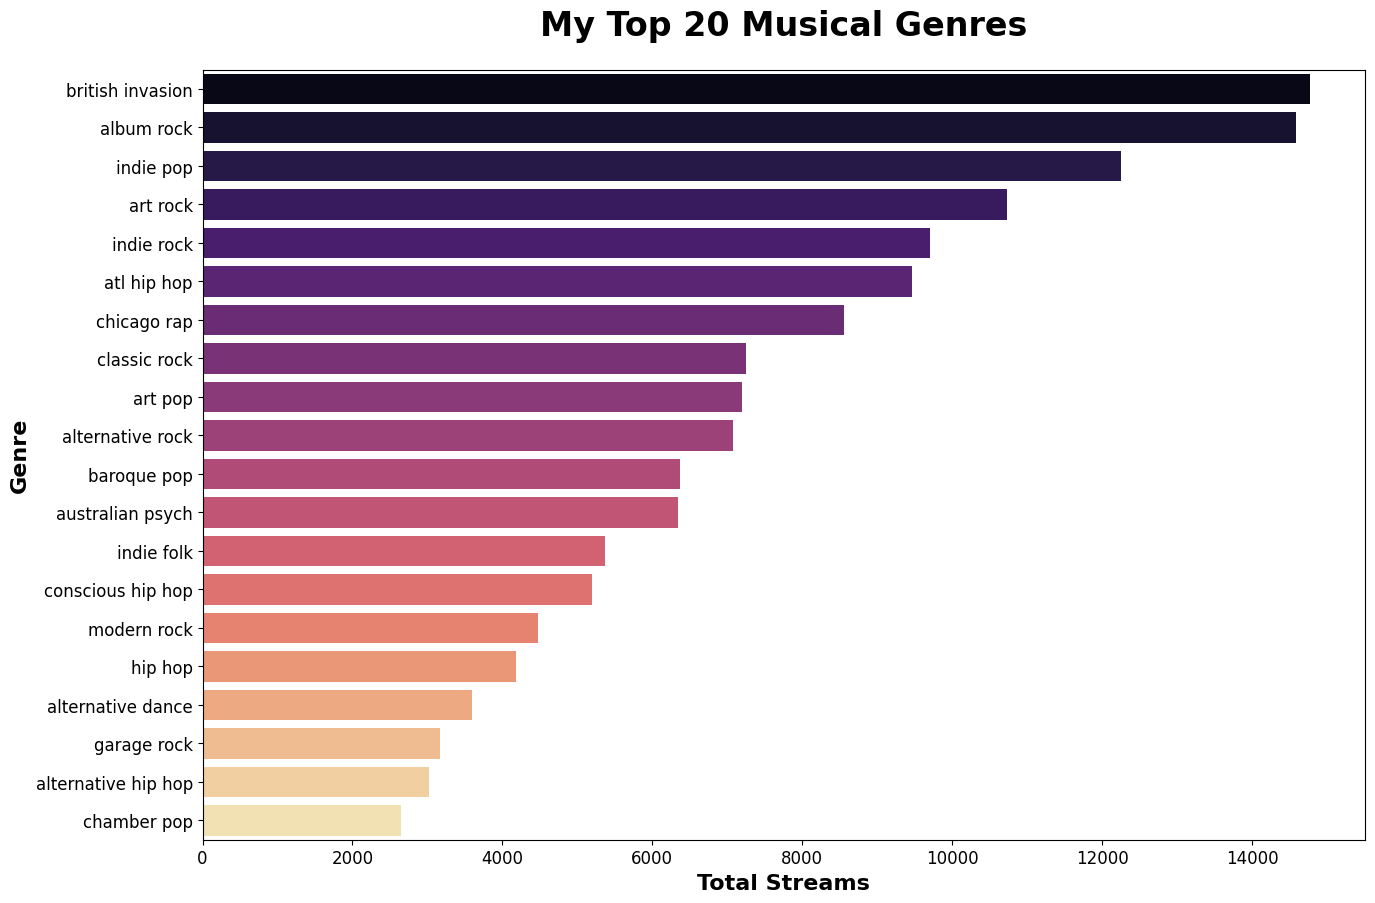

In [ ]:
top_20_genres = df_music[df_music['main_genre'] != 'Unknown']['main_genre'].value_counts().head(20)
plt.figure(figsize=(15, 10))
sns.barplot(
    x=top_20_genres.values,
    y=top_20_genres.index,
    palette='magma',
    hue=top_20_genres.index,
    legend=False
)
plt.title('My Top 20 Musical Genres', fontsize=24, fontweight='bold', pad=25)
plt.xlabel('Total Streams', fontsize=16, fontweight='bold')
plt.ylabel("Genre", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

This is a cool visual but we have to remember that it could be that every individual artist has it's own sub-genre. Either way, it demonstrates my test very well.

Now a heatmap for genres i listen to during hours of the week!

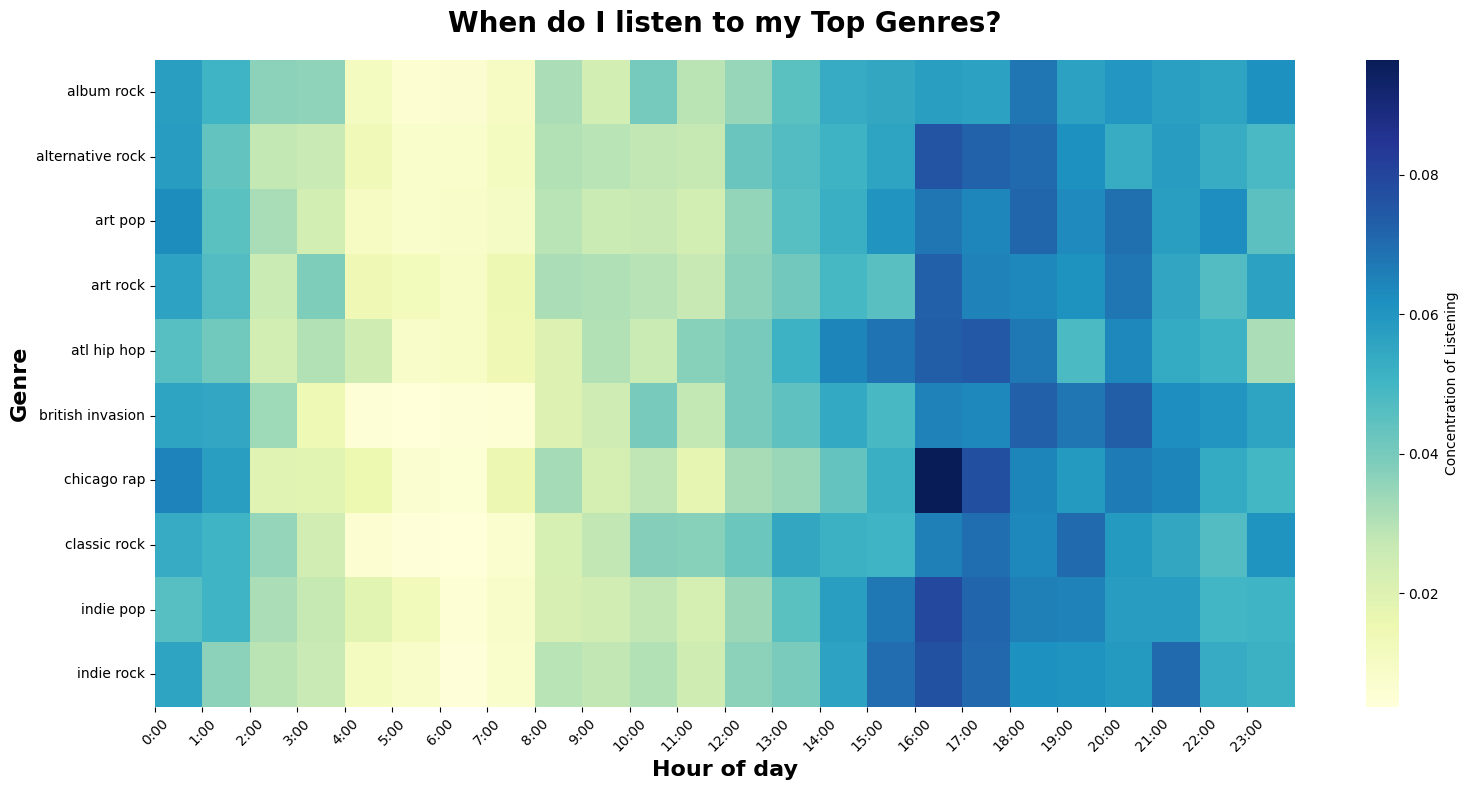

In [ ]:
df_music['hour'] = df_music['ts'].dt.hour

top_10_genres = df_music[df_music['main_genre'] != 'Unknown']['main_genre'].value_counts().head(10).index
df_heatmap = df_music[df_music['main_genre'].isin(top_10_genres)]

heatmap_data = df_heatmap.groupby(['main_genre', 'hour']).size().unstack(fill_value=0)

heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_norm, cmap="YlGnBu", annot=False, cbar_kws={'label': 'Concentration of Listening'})

plt.title('When do I listen to my Top Genres?', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Hour of day', fontsize=16, fontweight='bold')
plt.ylabel('Genre', fontsize=16, fontweight='bold')
plt.xticks(range(24), labels=[f'{i}:00' for i in range(24)], rotation=45)

plt.tight_layout()
plt.show()

This was also another whatever. As I've said before, I don't listen to genres by time of the day but by eras of my life. I'm very into one genre or artist or album for a week or a month and then I switch over. I won't listen to rap on Monday at 6 pm and then switch over to indie. I do wonder what was going on at 4 PM with Chicago Rap, though!

Now im gonna do a density plot of minutes listened versus time.

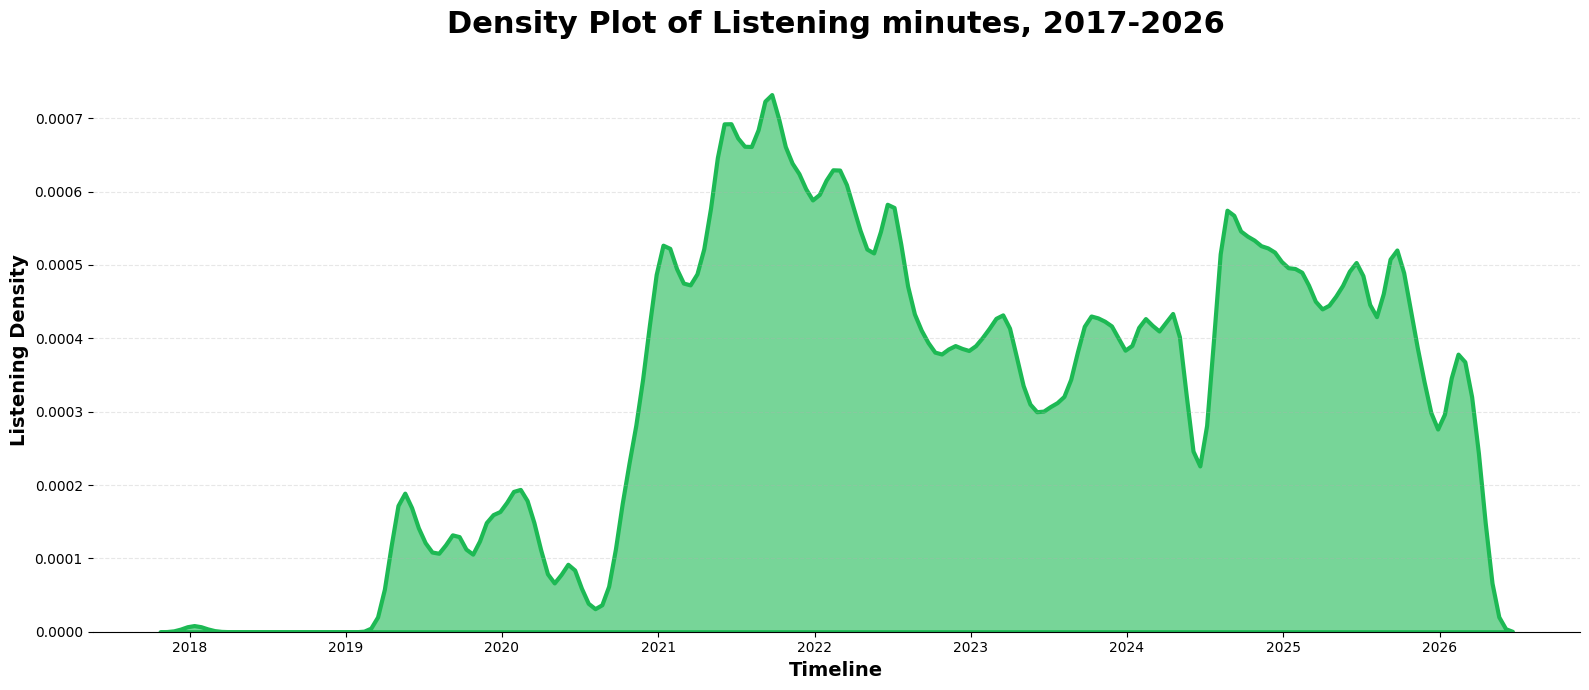

In [ ]:
plt.figure(figsize=(16, 7))

sns.kdeplot(
    data=df_music,
    x='ts',
    fill=True,
    color='#1DB954',
    alpha=0.6,
    linewidth=3,
    bw_adjust=0.4
)
plt.title('Density Plot of Listening minutes, 2017-2026', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('Timeline', fontsize=14, fontweight='bold')
plt.ylabel('Listening Density', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True)

plt.tight_layout()
plt.show()

I did this for my K-Mean visualization and for the presentation. Interesting how my listening picked up during Covid and goes down in the summers! The density axis is fairly meaningless. To get complexity and better demonstrate my listening history I used it. I assuem it means that per day/per hour/whatevr metric it used I was listening to .0000-.0007 of my total music.

/tmp/ipykernel_3141/1685715696.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_music['month_year'] = df_music['ts'].dt.to_period('M')
/tmp/ipykernel_3141/1685715696.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month_year', y='minutes_played', data=monthly_minutes, palette='viridis')


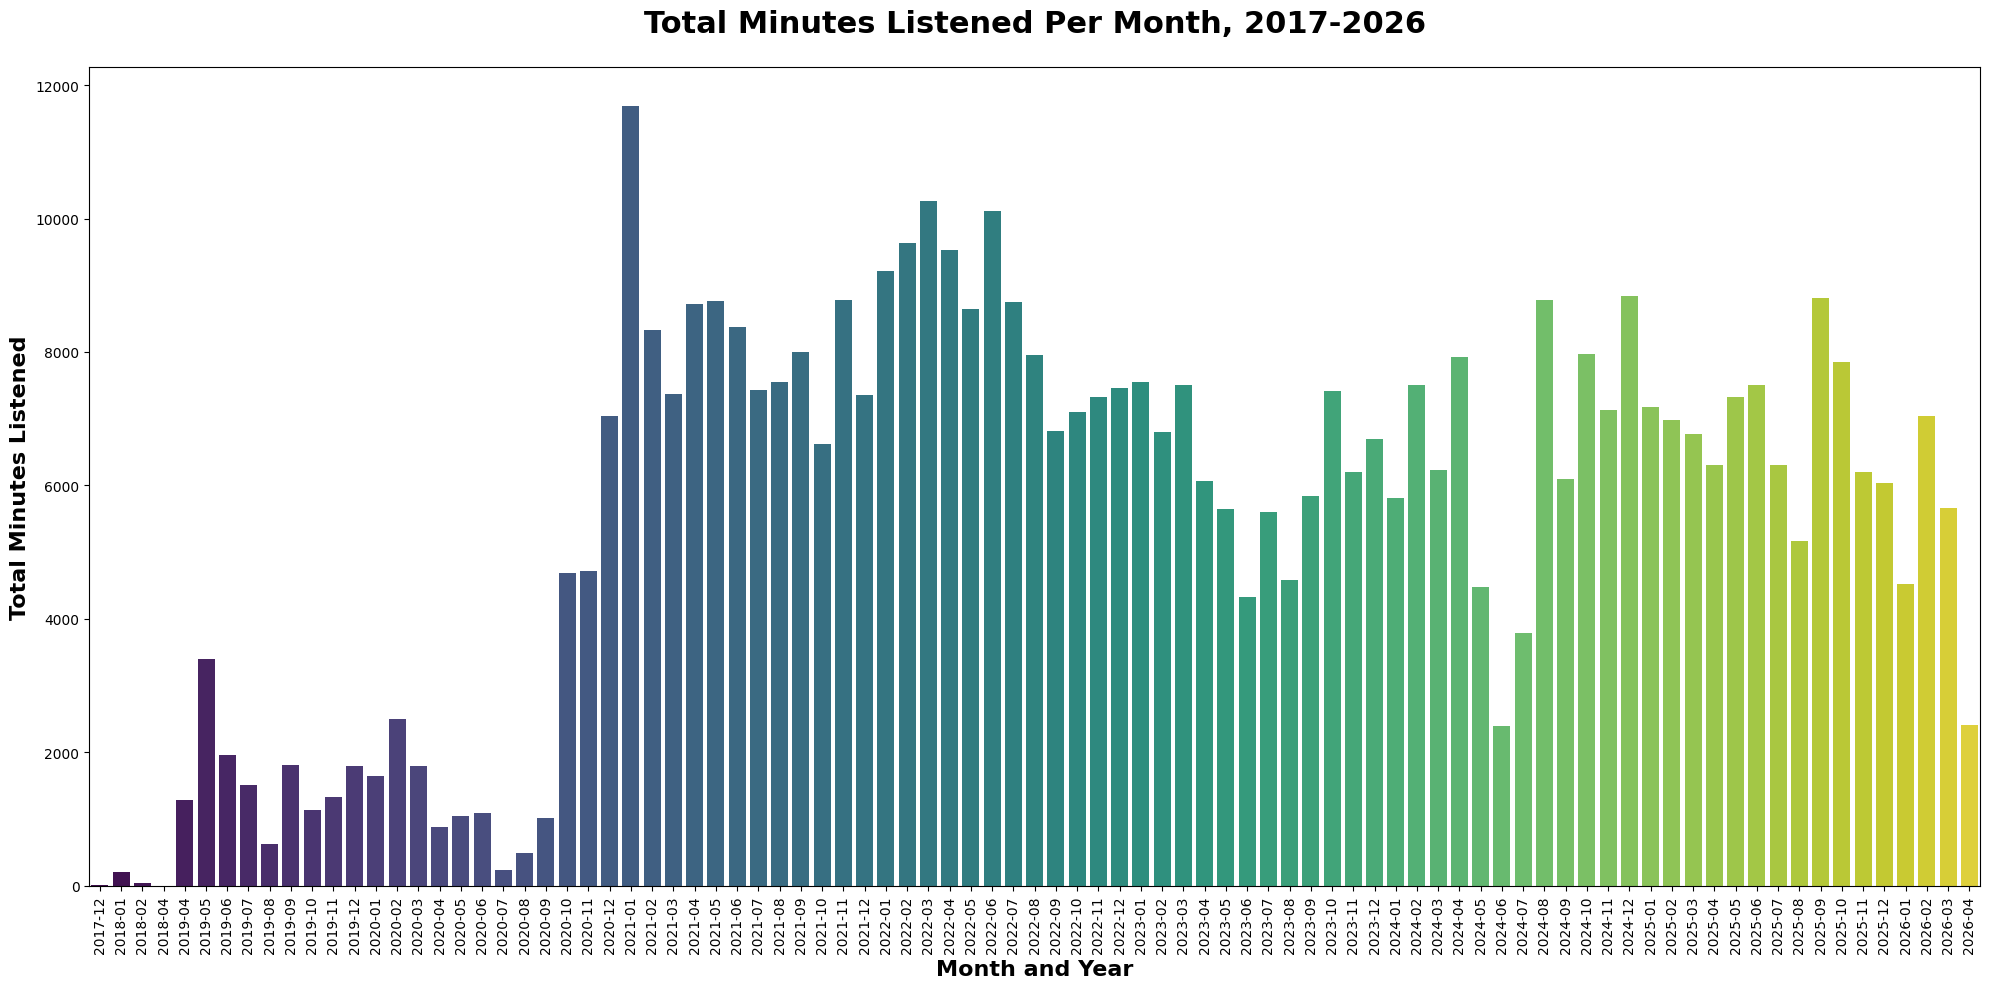

In [ ]:
df_music['month_year'] = df_music['ts'].dt.to_period('M')
monthly_minutes = df_music.groupby('month_year')['minutes_played'].sum().reset_index()
monthly_minutes['month_year'] = monthly_minutes['month_year'].astype(str)

plt.figure(figsize=(20, 10))
sns.barplot(x='month_year', y='minutes_played', data=monthly_minutes, palette='viridis')
plt.title('Total Minutes Listened Per Month, 2017-2026', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('Month and Year', fontsize=16, fontweight='bold')
plt.ylabel('Total Minutes Listened', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

These are attempts to better represent the total data but I really didn't like them visually. They tell less than the orginal graph or they look ugly (as the one below does).

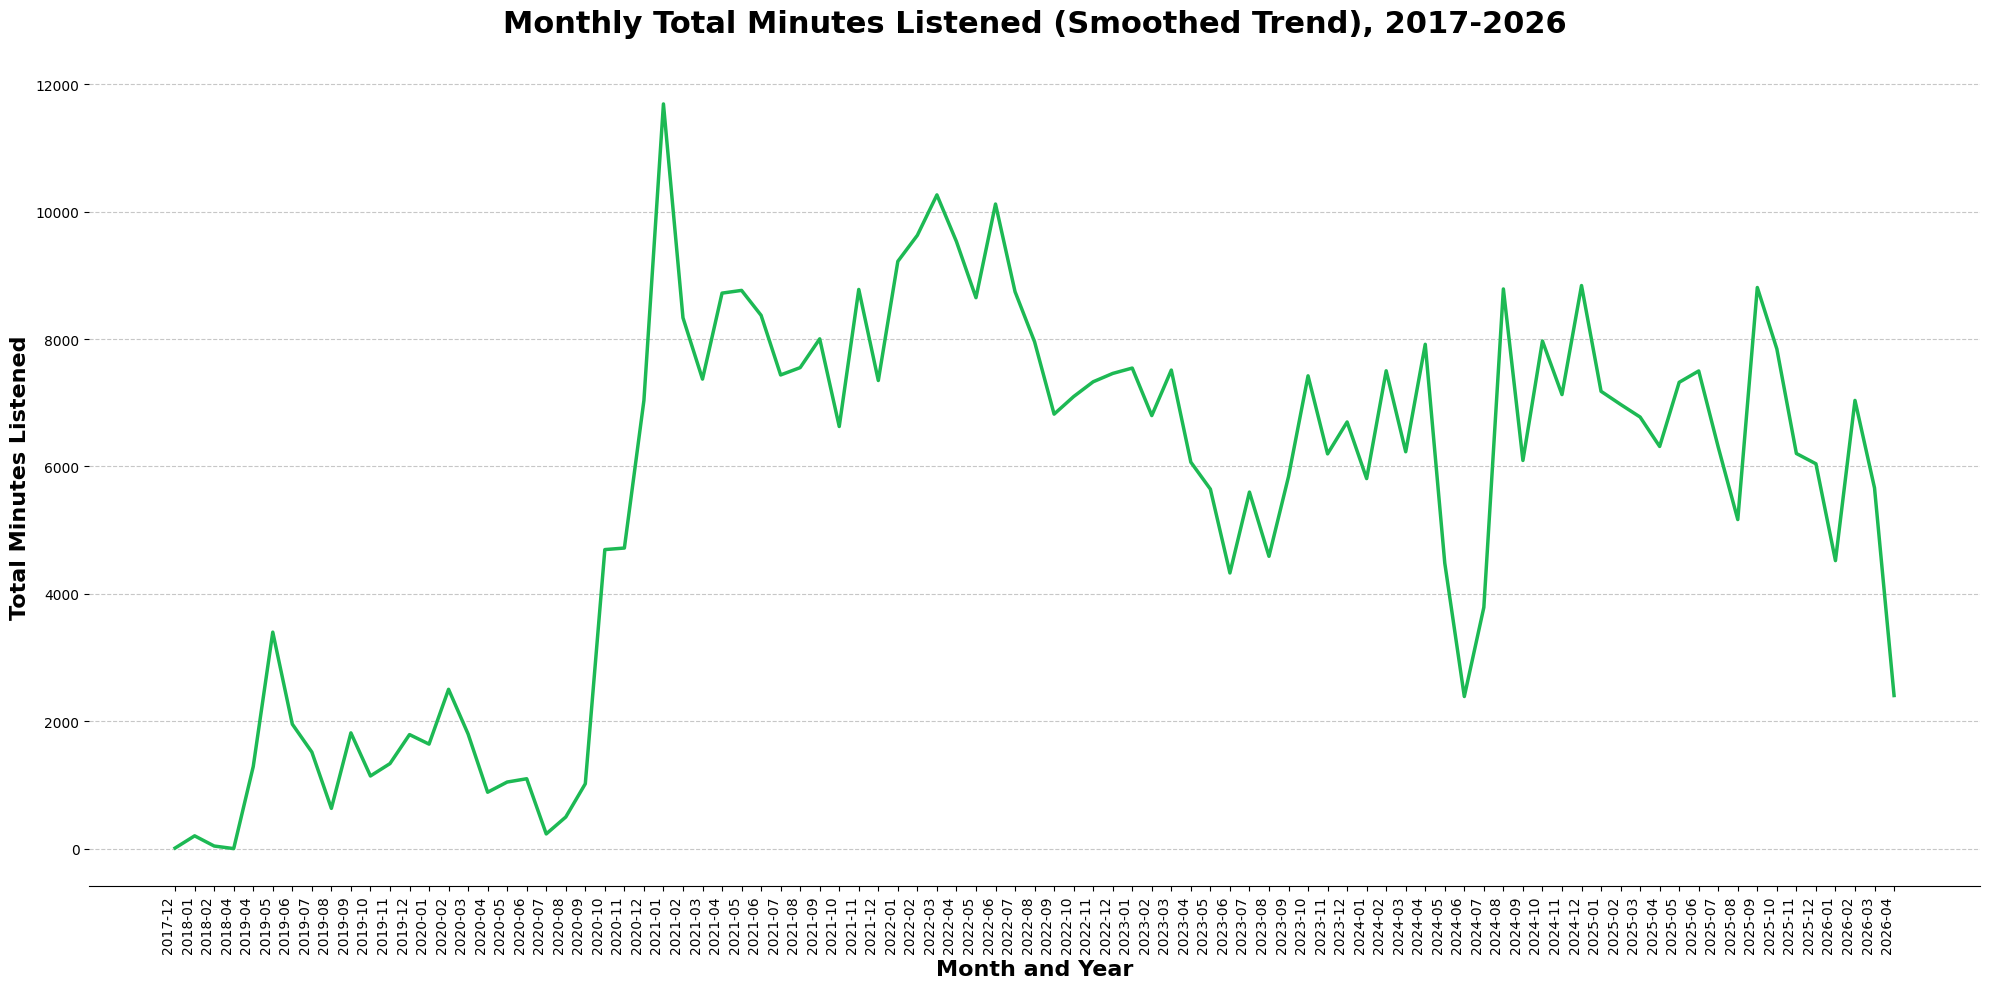

In [ ]:
plt.figure(figsize=(20, 10))
sns.lineplot(x='month_year', y='minutes_played', data=monthly_minutes, color='#1DB954', linewidth=2.5)
plt.title('Monthly Total Minutes Listened (Smoothed Trend), 2017-2026', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('Month and Year', fontsize=16, fontweight='bold')
plt.ylabel('Total Minutes Listened', fontsize=16, fontweight='bold')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [ ]:

big_five_mapping = {

    "Kanye West": "Rap", "Kendrick Lamar": "Rap", "Future": "Rap", "Young Thug": "Rap",
    "Playboi Carti": "Rap", "Travis Scott": "Rap", "LUCKI": "Rap", "JPEGMAFIA": "Rap",
    "JAY-Z": "Rap", "Tyler, The Creator": "Rap", "Joey Bada$$": "Rap", "Chief Keef": "Rap",
    "Summrs": "Rap", "Bladee": "Rap", "Earl Sweatshirt": "Rap", "Metro Boomin": "Rap",
    "MF DOOM": "Rap", "Kid Cudi": "Rap", "Baby Keem": "Rap", "BabyTron": "Rap",
    "Madvillain": "Rap", "KIDS SEE GHOSTS": "Rap", "Drake": "Rap", "Migos": "Rap",
    "Lil Baby": "Rap", "Lil Yachty": "Rap", "A Boogie Wit da Hoodie": "Rap", "Gunna": "Rap",
    "21 Savage": "Rap", "A$AP Rocky": "Rap", "Ecco2k": "Rap", "Veeze": "Rap",
    "Lil Uzi Vert": "Rap", "Takeoff": "Rap", "Rich Homie Quan": "Rap", "Ken Carson": "Rap",
    "Death Grips": "Rap", "Chance the Rapper": "Rap", "Nas": "Rap", "Childish Gambino": "Rap",
    "Meek Mill": "Rap", "Pharrell Williams": "Rap", "Beastie Boys": "Rap", "Post Malone": "Rap",
    "Yeat": "Rap", "J. Cole": "Rap", "Trippie Redd": "Rap", "Denzel Curry": "Rap",
    "Juice WRLD": "Rap", "Mac Miller": "Rap", "Pop Smoke": "Rap", "Lil Peep": "Rap",
    "Outkast": "Rap", "Fetty Wap": "Rap", "YNW Melly": "Rap", "Yung Lean": "Rap",
    "Freddie Gibbs": "Rap", "A$AP Mob": "Rap", "XXXTENTACION": "Rap",


    "The Beatles": "Rock", "Radiohead": "Rock", "Steely Dan": "Rock", "Kings of Leon": "Rock",
    "The Rolling Stones": "Rock", "Pink Floyd": "Rock", "The Strokes": "Rock",
    "Coldplay": "Rock", "Elton John": "Rock", "Wilco": "Rock", "The Beach Boys": "Rock",
    "The Clash": "Rock", "The Police": "Rock", "Fleetwood Mac": "Rock", "Nirvana": "Rock",
    "Joy Division": "Rock", "George Harrison": "Rock", "The Smile": "Rock",
    "Paul McCartney": "Rock", "Bob Dylan": "Rock", "Red Hot Chili Peppers": "Rock",
    "Stevie Wonder": "Rock", "The Killers": "Rock", "Talking Heads": "Rock", "Eagles": "Rock",
    "U2": "Rock", "Arctic Monkeys": "Rock", "John Lennon": "Rock", "Yeah Yeah Yeahs": "Rock",
    "Bruce Springsteen": "Rock", "The Replacements": "Rock", "The Byrds": "Rock",
    "John Mayer": "Rock", "David Bowie": "Rock", "The Smashing Pumpkins": "Rock",
    "The Flaming Lips": "Rock", "Jackson Browne": "Rock", "The Verve": "Rock",
    "The Alan Parsons Project": "Rock", "Yusuf / Cat Stevens": "Rock", "Pixies": "Rock",
    "Built To Spill": "Rock", "Electric Light Orchestra": "Rock", "R.E.M.": "Rock",
    "Led Zeppelin": "Rock", "Muse": "Rock", "America": "Rock", "Neil Young": "Rock",
    "The Velvet Underground": "Rock", "Dire Straits": "Rock", "Weezer": "Rock",
    "Tom Petty and the Heartbreakers": "Rock", "Oasis": "Rock", "Billy Joel": "Rock",
    "Chicago": "Rock", "The Mamas & The Papas": "Rock", "Jeff Buckley": "Rock",
    "Tom Petty": "Rock", "Daryl Hall & John Oates": "Rock", "Depeche Mode": "Rock",
    "The Kinks": "Rock", "Blur": "Rock", "The Animals": "Rock", "Genesis": "Rock",
    "Foreigner": "Rock", "Kasabian": "Rock", "TOTO": "Rock", "The Doobie Brothers": "Rock",
    "Green Day": "Rock", "The Who": "Rock", "Steve Miller Band": "Rock", "Wings": "Rock",
    "Allman Brothers Band": "Rock", "The Band": "Rock", "Van Morrison": "Rock",
    "Paramore": "Rock", "Tears For Fears": "Rock", "Queen": "Rock", "John Mellencamp": "Rock",
    "Derek & The Dominos": "Rock", "Steve Winwood": "Rock", "Queens of the Stone Age": "Rock",
    "The White Stripes": "Rock", "AC/DC": "Rock", "Pavement": "Rock", "Boston": "Rock",
    "Jimi Hendrix": "Rock", "Blue Öyster Cult": "Rock", "Foo Fighters": "Rock",
    "Crosby, Stills & Nash": "Rock", "Black Sabbath": "Rock", "Creedence Clearwater Revival": "Rock",
    "Sonic Youth": "Rock", "Rush": "Rock", "Bob Seger": "Rock", "The Doors": "Rock",
    "Eric Clapton": "Rock", "Soundgarden": "Rock", "Mötley Crüe": "Rock", "Blondie": "Rock",


    "Tame Impala": "Indie", "Arcade Fire": "Indie", "MGMT": "Indie",
    "Two Door Cinema Club": "Indie", "The Smiths": "Indie", "Big Thief": "Indie",
    "Band of Horses": "Indie", "Interpol": "Indie", "Phoenix": "Indie", "Animal Collective": "Indie",
    "The Cure": "Indie", "Doves": "Indie", "The Maccabees": "Indie", "Vampire Weekend": "Indie",
    "STRFKR": "Indie", "The Shins": "Indie", "Car Seat Headrest": "Indie",
    "Black Country, New Road": "Indie", "Alvvays": "Indie", "Night Moves": "Indie",
    "Cage The Elephant": "Indie", "Grizzly Bear": "Indie", "Mac DeMarco": "Indie",
    "Broken Bells": "Indie", "The Whitest Boy Alive": "Indie", "Neutral Milk Hotel": "Indie",
    "Death Cab for Cutie": "Indie", "Modest Mouse": "Indie", "Broken Social Scene": "Indie",
    "MJ Lenderman": "Indie", "The Big Pink": "Indie", "King Gizzard & The Lizard Wizard": "Indie",
    "Foster The People": "Indie", "Bleachers": "Indie", "The Drums": "Indie",
    "Andy Shauf": "Indie", "The Horrors": "Indie", "Sweet Trip": "Indie",
    "The War On Drugs": "Indie", "Kurt Vile": "Indie", "The Middle East": "Indie",
    "The Rapture": "Indie", "Clap Your Hands Say Yeah": "Indie", "The Temper Trap": "Indie",
    "Real Estate": "Indie", "Sharon Van Etten": "Indie", "GROUPLOVE": "Indie",
    "Young the Giant": "Indie", "The Libertines": "Indie", "The Walkmen": "Indie",
    "Duster": "Indie", "Weyes Blood": "Indie", "Rogue Wave": "Indie", "Dr. Dog": "Indie",
    "Foals": "Indie", "Cigarettes After Sex": "Indie", "Adrianne Lenker": "Indie",
    "Generationals": "Indie", "TV On The Radio": "Indie", "Peter Bjorn and John": "Indie",
    "Beirut": "Indie", "Peach Pit": "Indie", "Unknown Mortal Orchestra": "Indie",
    "Julian Casablancas": "Indie", "Mazzy Star": "Indie", "Matt and Kim": "Indie",
    "Slowdive": "Indie", "Toro y Moi": "Indie", "Miami Horror": "Indie", "Bombay Bicycle Club": "Indie",
    "The Church": "Indie", "Neon Indian": "Indie", "Mitski": "Indie", "Cold War Kids": "Indie",
    "WALK THE MOON": "Indie", "Fiona Apple": "Indie", "of Montreal": "Indie",
    "Cocteau Twins": "Indie", "Silversun Pickups": "Indie", "The National": "Indie",
    "Lykke Li": "Indie", "The Kooks": "Indie",


    "Father John Misty": "Folk", "Simon & Garfunkel": "Folk", "Fleet Foxes": "Folk",
    "Paul Simon": "Folk", "Sufjan Stevens": "Folk", "Elliott Smith": "Folk",
    "Nick Mulvey": "Folk", "Andrew Bird": "Folk", "Sun Kil Moon": "Folk",
    "The Head And The Heart": "Folk", "Don McLean": "Folk", "Harry Nilsson": "Folk",
    "Iron & Wine": "Folk", "Bon Iver": "Folk", "The Decemberists": "Folk",
    "Bob Marley & The Wailers": "Folk", "Songs: Ohia": "Folk", "Whitney": "Folk",
    "Whiskeytown": "Folk", "James Taylor": "Folk", "Fruit Bats": "Folk",
    "The Avett Brothers": "Folk", "The Barr Brothers": "Folk", "Nathan Evans": "Folk",
    "Mumford & Sons": "Folk", "Grateful Dead": "Folk", "Glen Campbell": "Folk",
    "Billy Bragg": "Folk", "Houndmouth": "Folk", "Johnny Cash": "Folk",
    "The Lumineers": "Folk", "Nick Drake": "Folk", "The Monkees": "Folk", "Joni Mitchell": "Folk",


    "Gorillaz": "Electronic", "LCD Soundsystem": "Electronic", "Metronomy": "Electronic",
    "New Order": "Electronic", "Passion Pit": "Electronic", "Daft Punk": "Electronic",
    "M83": "Electronic", "Hot Chip": "Electronic", "Cut Copy": "Electronic",
    "Empire Of The Sun": "Electronic", "Poolside": "Electronic", "Kavinsky": "Electronic",
    "The Naked And Famous": "Electronic", "Beach House": "Electronic", "M.I.A.": "Electronic",
    "Duran Duran": "Electronic", "Miike Snow": "Electronic", "Bag Raiders": "Electronic",
    "The Avalanches": "Electronic", "Kavinsky": "Electronic"
}


df_music['broad_genre'] = df_music['artist'].map(big_five_mapping).fillna('Other')


df_analysis = df_music[df_music['broad_genre'] != 'Other'].copy()

print(f"Mapped {len(df_analysis)} streams to the Big 5 categories.")
print(df_analysis['broad_genre'].value_counts())

Mapped 166167 streams to the Big 5 categories.
broad_genre
Rock          66164
Indie         38084
Rap           34961
Folk          15703
Electronic    11255
Name: count, dtype: int64


This is from ChatGPT as well. I wanted Macro-Genres so I could use a heatmap!

/tmp/ipykernel_3141/665288576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analysis, y='broad_genre', order=order, palette='Spectral')


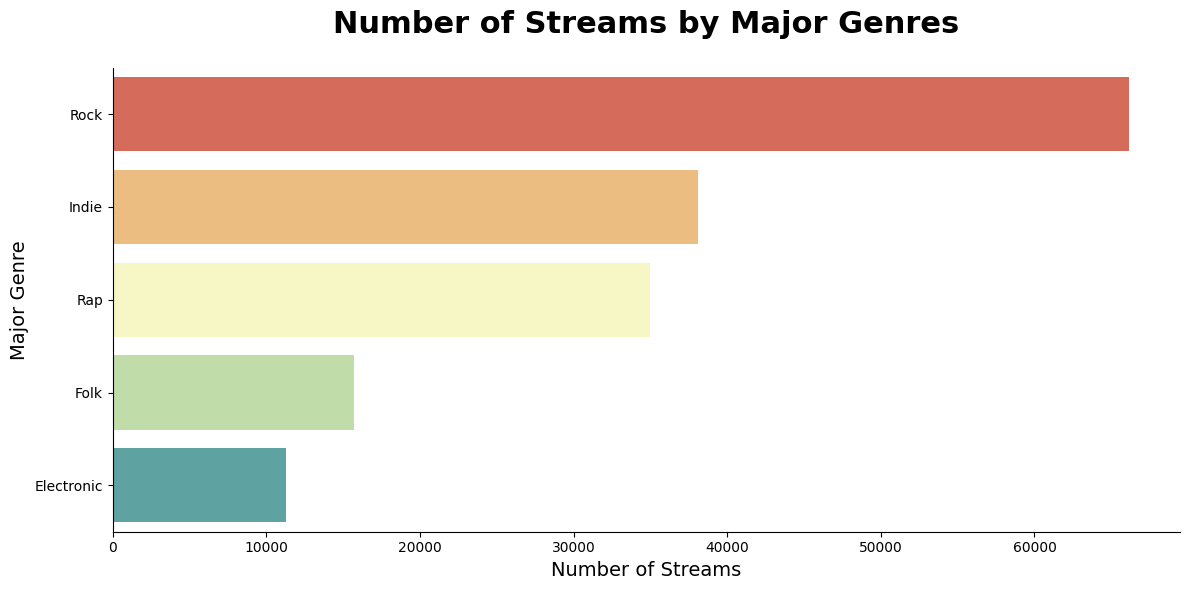

In [ ]:
plt.figure(figsize=(12, 6))
order = ['Rock', 'Indie', 'Rap', 'Folk', 'Electronic']
sns.countplot(data=df_analysis, y='broad_genre', order=order, palette='Spectral')
plt.title('Number of Streams by Major Genres', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('Number of Streams', fontsize=14)
plt.ylabel('Major Genre', fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

Interesting that Indie and Rap are pretty similar while Rock is the clear leader. I can also say that Folk and Electronic can be indistinguishable from Indie, so maybe that's why they look competitive.

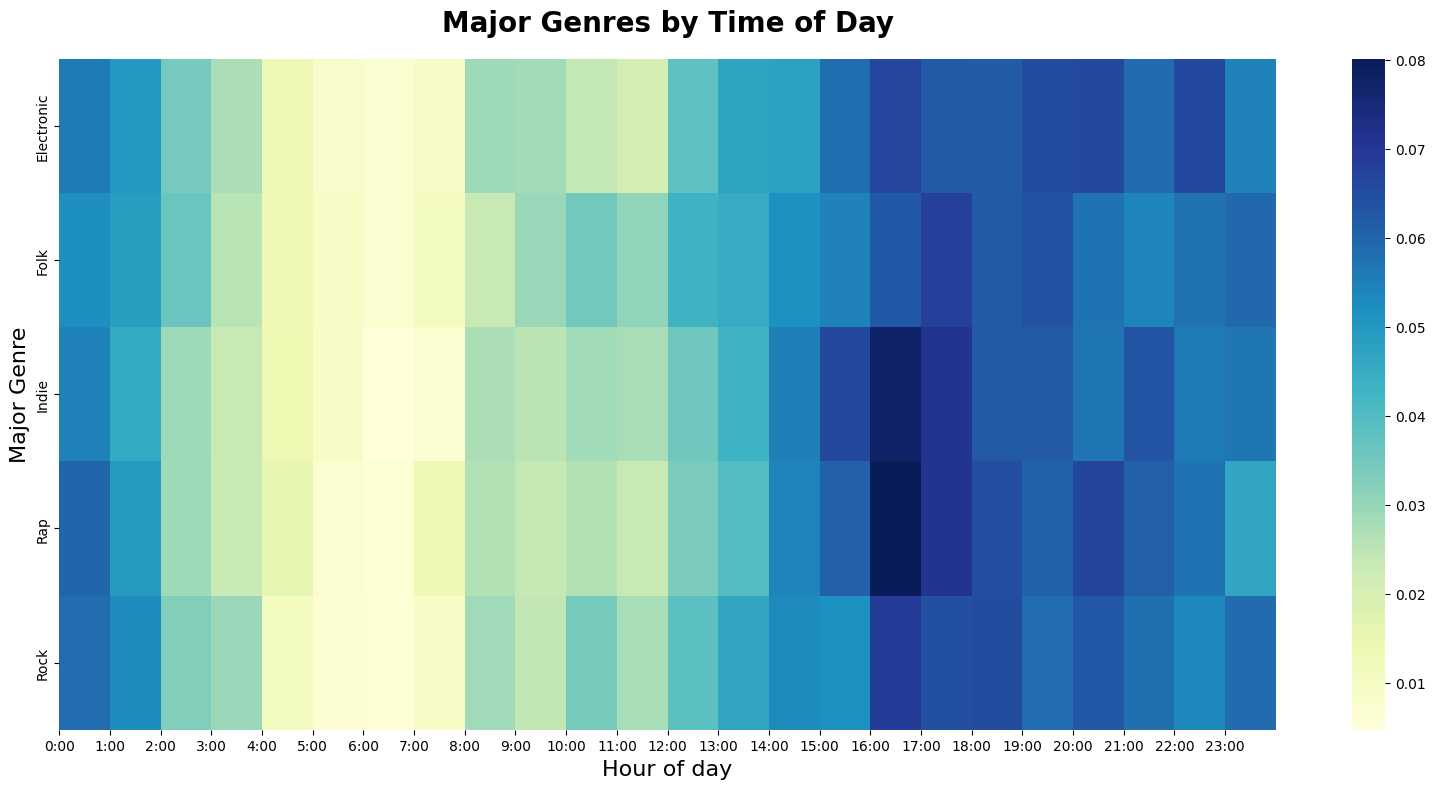

In [ ]:
heatmap_data = df_analysis.groupby(['broad_genre', 'hour']).size().unstack(fill_value=0)
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_norm, cmap="YlGnBu", annot=False)

plt.title("Major Genres by Time of Day", fontsize=20, fontweight="bold", pad=20)
plt.xlabel('Hour of day', fontsize=16)
plt.ylabel('Major Genre', fontsize=16)
plt.xticks(range(24), labels=[f'{i}:00' for i in range(24)])
plt.tight_layout()
plt.show()

I used this to demonstrate the time of the day doesn't have a big discernable impact on my listening choices. Rap and Indie were very heavy at 4 pm, but I don't know what that says about me.

Going to run a K-Mean clust on month, year, shuffle, and the original genre because I usually listen to certain artsits/genres for weeks at a time.

In [ ]:
from sklearn.cluster import KMeans

df_phases = df_music.copy()


df_phases['month'] = df_phases['ts'].dt.month

genre_dummies = pd.get_dummies(df_phases['main_genre'], prefix='genre')
X = pd.concat([df_phases[['month', 'year', 'shuffle']], genre_dummies], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
for k in range(1, 15):
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  km.fit(X_scaled)
  inertia.append(km.inertia_)

k_phases = 8
kmeans = KMeans(n_clusters=k_phases, random_state=42, n_init=10)
df_phases['cluster'] = kmeans.fit_predict(X_scaled)

phase_summary = df_phases.groupby('cluster').agg({
    'main_genre': lambda x: x.mode()[0],
    'month': 'mean',
    'year': 'mean',
    'shuffle': 'mean'
}).sort_values(by=['year', 'month'])

print("My Personal Musical Eras")
print(phase_summary)

My Personal Musical Eras
                main_genre     month         year   shuffle
cluster                                                    
2         british invasion  5.993024  2021.890053  0.675286
3                indie pop  6.199723  2022.432732  0.743004
0               album rock  6.849891  2022.505929  0.689912
5             classic rock  5.743692  2022.547911  0.686888
4              chicago rap  7.355031  2022.554400  0.676639
6                  Unknown  6.390519  2023.110312  0.678020
1        alternative dance  7.373642  2023.333519  0.721092
7         alternative rock  7.005653  2023.356416  0.679197


This was interesting but totally useless. I wanted to track my life in eras of music listening. Here it all centered around 2021-2023 because that's when I listened to the most msuic. I ahd to do a little vibe coding to figure out how to make the eras temporal and separate.


In [ ]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


df_clean = df_music[df_music['main_genre'] != 'Unknown'].copy()


start_date = df_clean['ts'].min()
df_clean['days_since_start'] = (df_clean['ts'] - start_date).dt.days


genre_dummies = pd.get_dummies(df_clean['main_genre'], prefix='genre')
X = pd.concat([df_clean[['days_since_start', 'shuffle']], genre_dummies], axis=1)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_scaled[:, 0] *= 20

k_eras = 10
kmeans = KMeans(n_clusters=k_eras, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)


phase_summary = df_clean.groupby('cluster').agg({
    'ts': ['min', 'max'],
    'main_genre': lambda x: x.mode()[0],
    'shuffle': 'mean',
    'song': 'count'
})

phase_summary.columns = ['Start_Date', 'End_Date', 'Top_Genre', 'Shuffle_Rate', 'Stream_Count']
phase_summary = phase_summary.sort_values(by='Start_Date')

print("--- YOUR CHRONOLOGICAL MUSICAL ERAS ---")
print(phase_summary)

# 6. Song Discovery: The "Phase Identity"
print("\n--- TOP TRACKS PER ERA ---")
for cluster_id in phase_summary.index:
    start = phase_summary.loc[cluster_id, 'Start_Date'].strftime('%Y-%m')
    end = phase_summary.loc[cluster_id, 'End_Date'].strftime('%Y-%m')
    genre = phase_summary.loc[cluster_id, 'Top_Genre']

    print(f"\nERA {cluster_id}: {start} to {end} ({genre})")
    top_songs = df_clean[df_clean['cluster'] == cluster_id]['song'].value_counts().head(5)
    print(top_songs)

--- YOUR CHRONOLOGICAL MUSICAL ERAS ---
                       Start_Date                  End_Date  \
cluster                                                       
9       2017-12-30 17:03:37-05:00 2020-05-26 14:18:17-04:00   
7       2020-05-14 18:21:01-04:00 2021-05-20 17:16:31-04:00   
1       2021-03-09 14:54:43-05:00 2021-10-28 12:12:07-04:00   
6       2021-09-21 20:40:54-04:00 2022-05-16 13:54:25-04:00   
3       2022-04-11 14:10:47-04:00 2022-12-21 16:02:26-05:00   
8       2022-11-12 21:02:26-05:00 2023-08-31 18:37:04-04:00   
4       2023-08-09 02:03:49-04:00 2024-05-28 19:44:07-04:00   
0       2024-04-26 06:42:36-04:00 2025-01-29 17:02:06-05:00   
5       2024-12-28 20:25:16-05:00 2025-08-27 18:22:23-04:00   
2       2025-07-14 15:36:16-04:00 2026-04-13 16:16:25-04:00   

                 Top_Genre  Shuffle_Rate  Stream_Count  
cluster                                                 
9               album rock      0.839796          9981  
7               album rock      

This was pretty awesome. As I understood it, X_scaled somehow made them temporally ordered. I also shows what songs I listened to during that time and how much so I could then name them! Also, you can see how shuffle rate goes up and down considering whetehr I'm listening to artists with great albums or artists with a good collection of songs.

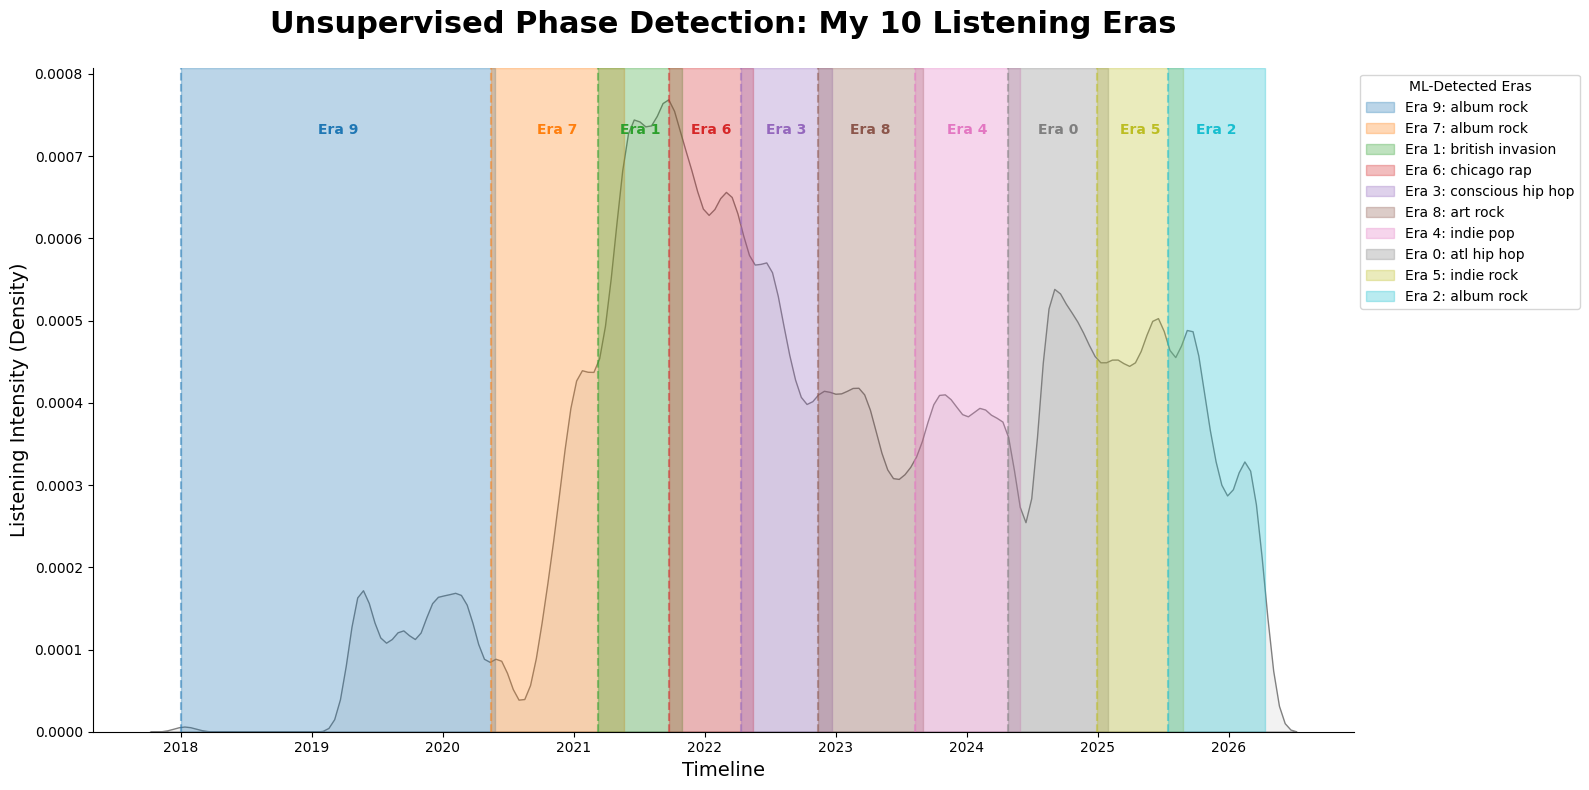

In [ ]:


df_plot = df_clean.copy()

plt.figure(figsize=(16, 8))

sns.kdeplot(data=df_plot, x='ts', fill=True, color='grey', alpha=0.1, bw_adjust=0.5)

colors = sns.color_palette("tab10", n_colors=len(phase_summary))

for i, (cluster_id, row) in enumerate(phase_summary.iterrows()):
    plt.axvspan(row['Start_Date'], row['End_Date'],
                color=colors[i], alpha=0.3, label=f"Era {cluster_id}: {row['Top_Genre']}")

    plt.axvline(row['Start_Date'], color=colors[i], linestyle='--', alpha=0.5)

    midpoint = row['Start_Date'] + (row['End_Date'] - row['Start_Date']) / 2
    plt.text(midpoint, plt.gca().get_ylim()[1]*0.9, f"Era {cluster_id}",
             horizontalalignment='center', fontweight='bold', color=colors[i])

plt.title('Unsupervised Phase Detection: My 10 Listening Eras', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('Timeline', fontsize=14)
plt.ylabel('Listening Intensity (Density)', fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="ML-Detected Eras")


sns.despine()
plt.tight_layout()
plt.savefig('ml_density_eras.png', dpi=300)
plt.show()

This is my first look of the finished graph. I thought it was super awesome but I obviously needed to input actual titles which were easy when I looked at what songs I had been listening to!

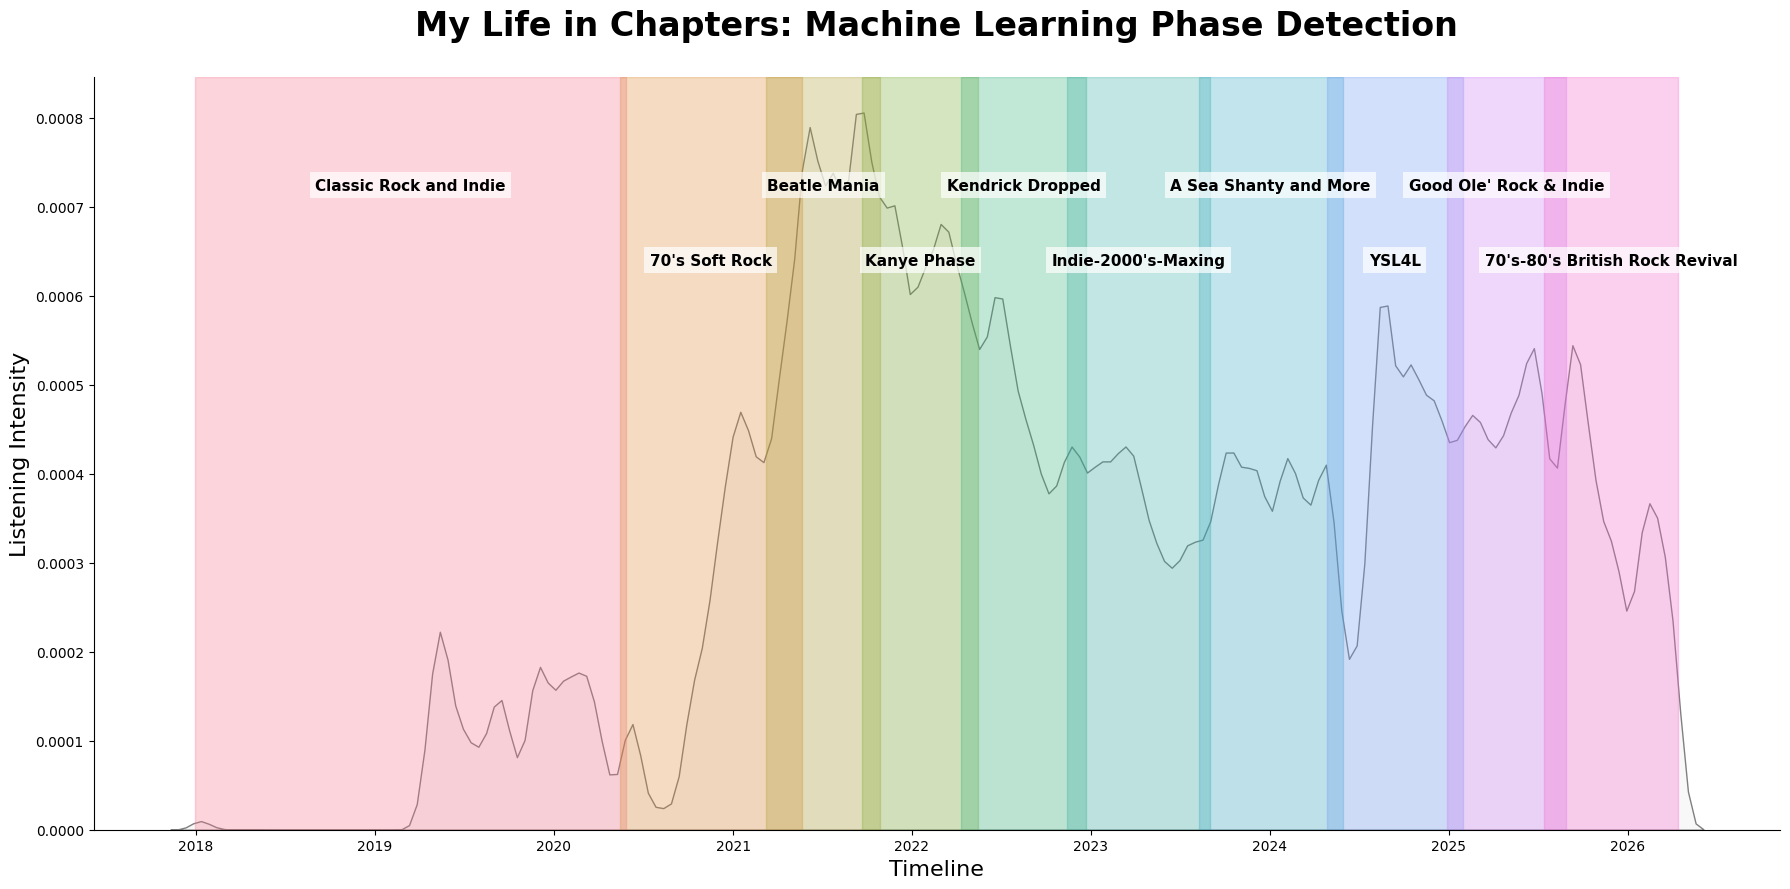

In [ ]:

era_names = {
    9: "Classic Rock and Indie",
    7: "70's Soft Rock",
    1: "Beatle Mania",
    6: "Kanye Phase",
    3: "Kendrick Dropped",
    8: "Indie-2000's-Maxing",
    4: "A Sea Shanty and More",
    0: "YSL4L",
    5: "Good Ole' Rock & Indie",
    2: "70's-80's British Rock Revival"
}

phase_summary['Era_Name'] = phase_summary.index.map(era_names)

plt.figure(figsize=(18, 9))

sns.kdeplot(data=df_clean, x='ts', fill=True, color='grey', alpha=0.05, bw_adjust=0.3)

colors = sns.color_palette("husl", n_colors=len(phase_summary))

for i, (cluster_id, row) in enumerate(phase_summary.iterrows()):

    plt.axvspan(row['Start_Date'], row['End_Date'], color=colors[i], alpha=0.3)


    midpoint = row['Start_Date'] + (row['End_Date'] - row['Start_Date']) / 2

    y_pos = plt.gca().get_ylim()[1] * (0.85 if i % 2 == 0 else 0.75)

    plt.text(midpoint, y_pos, row['Era_Name'],
             horizontalalignment='center', fontweight='bold',
             fontsize=11, color='black', rotation=0,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title('My Life in Chapters: Machine Learning Phase Detection', fontsize=24, fontweight='bold', pad=30)
plt.xlabel('Timeline', fontsize=16)
plt.ylabel('Listening Intensity', fontsize=16)
sns.despine()

plt.tight_layout()
plt.savefig('my_named_musical_eras.png', dpi=300)
plt.show()

Here is the magnum opus! As I've repeatedly said, I listen to music in eras, not daily or weekly moods. This was awesome and it also showed that my LLM generated genres were accurate to what I listen to in real life. One cool take-away: The most I ever listened to was when I was really into the Beatles! Although I no longer listen to them as much, listening fatigue is real, I can probably identify them as my favourite artist to listen to based on this graph.